# Realistic Process Analysis Example: ProMiSE P1

This notebook reconstructs the process mining analysis performed by participant **P1** in the ProMiSE study. Based on the recorded analysis session, it follows the participant’s exploration of the **Road Traffic Fines** event log and their investigation of the circumstances in which fines and related expenses are not paid in full.

The participant’s actions and findings are reproduced in Python where possible, with approximations used when the original Celonis functionality cannot be replicated exactly.

In [113]:
%pip install -q pandas pm4py graphviz

import pandas as pd
import pm4py
from IPython.display import Image, display
from pathlib import Path
import os
import shutil
from pathlib import Path

Note: you may need to restart the kernel to use updated packages.


## Road Traffic Fines Event Log

The **Road Traffic Fines** event log is a well-known benchmark dataset in process mining that captures the lifecycle of road traffic fines managed by local police departments in Italy.

The event log was extracted from an operational PostgreSQL database and records the administrative process followed from the creation of a fine until its resolution. Each **case** corresponds to a single traffic fine, while each **event** represents an activity executed during the management of that fine.

The process is regulated by Italian law, which defines several legal deadlines and constraints governing notifications, appeals, penalties, and debt collection.

### Activity Description

| Activity | Description |
|----------|-------------|
| **Create Fine** | The initial creation of the fine in the information system. It initializes the event log attributes **amount**, **dismissal**, **points**, and **totalPaymentAmount**. |
| **Send Fine** | A notification about the fine is sent by post to the offender. |
| **Insert Fine Notification** | The notification is received by the offender. |
| **Add Penalty** | An additional penalty is applied. |
| **Payment** | A payment made by the offender is registered. |
| **Send for Credit Collection** | Unpaid fines are sent for credit collection. A separate process is started by a collection agency to collect the money of the unpaid fines. |
| **Insert Date Appeal to Prefecture** | The offender appeals against the fine to the prefecture*. |
| **Send Appeal to Prefecture** | The appeal is sent to the prefecture by the local police. |
| **Receive Result Appeal from Prefecture** | The local police receives the result of the appeal.** |
| **Notify Result Appeal to Offender** | The local police informs the offender of the appeal result.** |
| **Appeal to Judge** | The offender appeals against the fine to a judge. |

\* A prefecture in Italy is an administrative body representing the national government in each province.

\** If the prefecture dismisses the fine, the appeal is deemed accepted and the obligation to pay the fine extinguishes. In this case, there is no need for the police to receive the result from the prefecture (*Receive Result Appeal from Prefecture*) and notify the offender (*Notify Result Appeal to Offender*).

---

### Event Log Attributes

| Attribute | Description |
|-----------|-------------|
| **amount** | The amount due to be paid for the fine (including the penalty amount if one is added). |
| **article** | The number of the article of the Italian road-traffic law that was violated by the offender (e.g., article 157 refers to stopping and parking vehicles). |
| **dismissal** | A flag indicating whether and by whom the fine is dismissed. It is initialized to **NIL**. Known values are:<br>• **G**: dismissed by the judge<br>• **#**: dismissed by the prefecture<br>• **NIL**: not dismissed, i.e., payment is required.<br>Several additional values exist whose semantics are unknown. |
| **expense** | The additional amount due to be paid for postal expenses. |
| **lastSent** | N/A. |
| **matricola** | N/A (probably refers to the matriculation number of the car). |
| **notificationType** | A flag indicating to whom the fine refers.<br>• **P**: car owner<br>• **C**: car driver |
| **resource** | A numeric code identifying the employee who handled the case. |
| **paymentAmount** | The amount paid by the offender in one transaction. |
| **points** | Penalty points deducted from the driving license. In Italy, each driver starts with 20 points and may lose points depending on the severity of the offence. |
| **totalPaymentAmount** | The cumulative amount paid by the offender. It is always initialized to **0.0**. |
| **vehicleClass** | A flag indicating the type of vehicle driven or owned by the offender. The semantics of the values are unknown. |

---

### Normative Temporal Constraints

The management of road traffic fines must comply with several temporal constraints established by Italian law.

| Constraint | Description |
|------------|-------------|
| **Create Fine → Insert Fine Notification** | The fine notification must be sent within **90 days** of the fine creation. If this constraint is violated, the obligation to pay the fine is cancelled. |
| **Insert Fine Notification → Add Penalty** | If the offender does not pay the fine within **60 days** after being notified, an additional penalty is applied. |
| **Insert Fine Notification → Insert Date Appeal to Prefecture / Appeal to Judge** | After receiving the notification, the offender may appeal to either the prefecture or a judge within **60 days**. |
| **Create Fine → Send for Credit Collection** | Although not prescribed by law, it is known that it usually takes at least **180 days** after the fine has been created before the process proceeds to credit collection. |

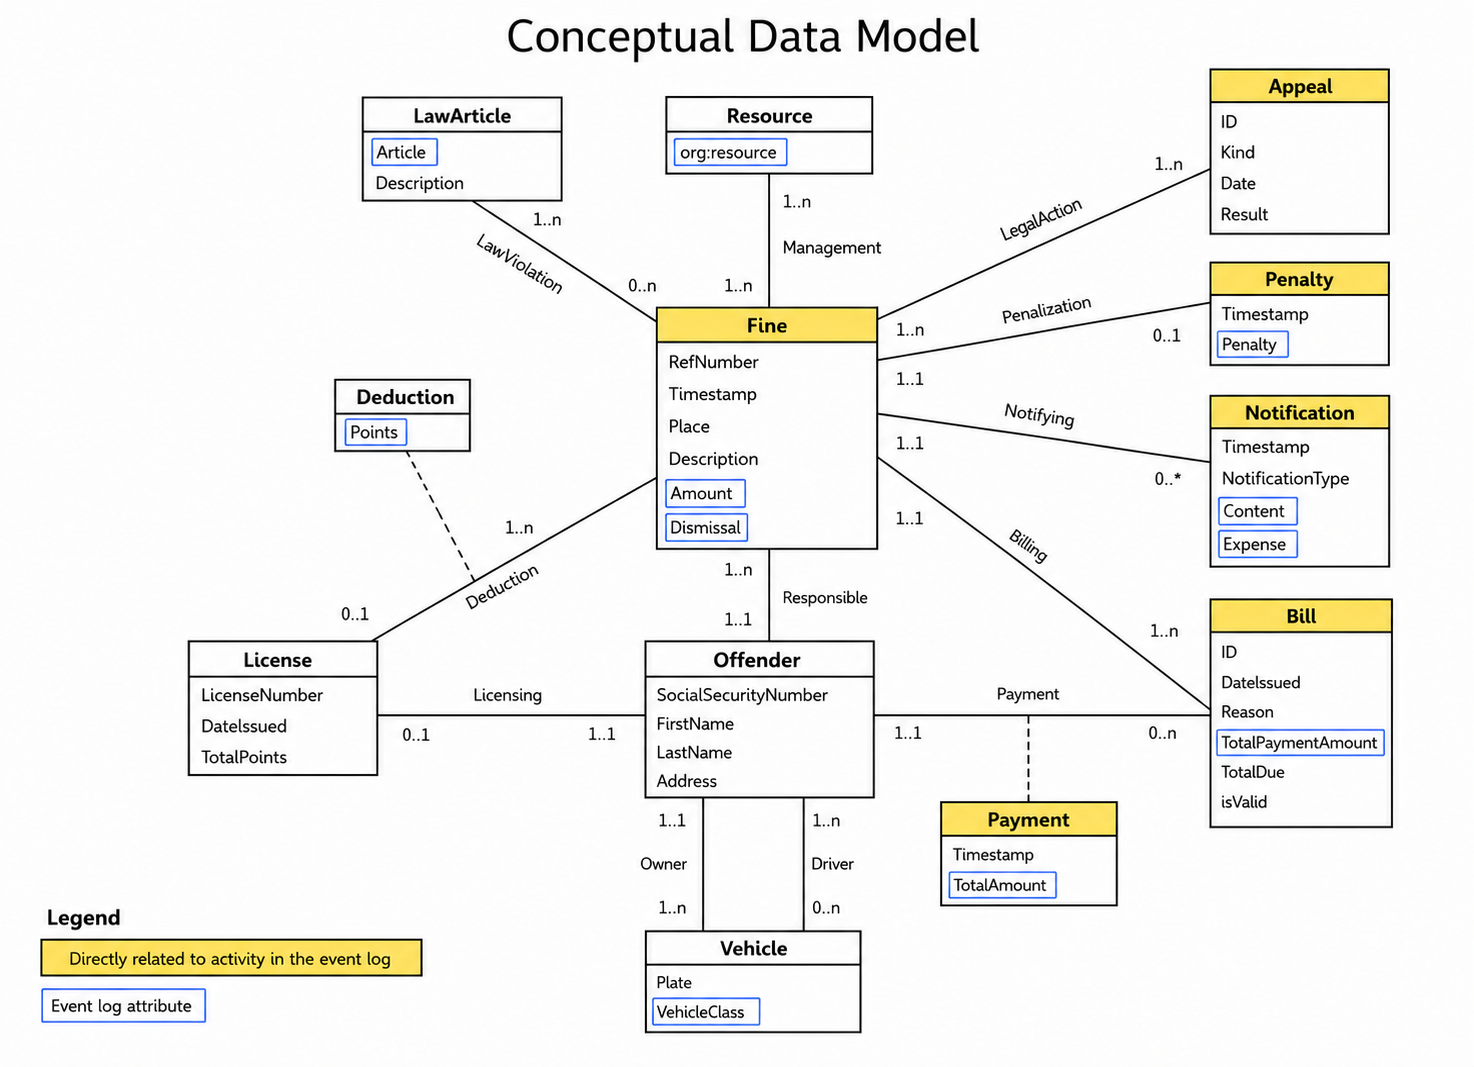

In [114]:
model_path = Path("Model.png")

if not model_path.exists():
    raise FileNotFoundError(f"Process-model image not found: {model_path.resolve()}")

display(Image(filename=str(model_path), width=850))

### Importing the log

In [115]:
CASE_ID_COL, TIMESTAMP_COL, ACTIVITY_COL = "Case ID", "Complete Timestamp", "Activity"
path_to_log = Path("dataset/Road_Traffic_Fine_Management_Process.csv")

if not path_to_log.exists():
    raise FileNotFoundError(f"Event-log CSV not found: {path_to_log.resolve()}")

df = pd.read_csv(path_to_log, dtype={"Resource": str, "matricola": str}, parse_dates=[TIMESTAMP_COL])
df = df.sort_values([CASE_ID_COL, TIMESTAMP_COL], ignore_index=True)
log = pm4py.format_dataframe(df, case_id=CASE_ID_COL, activity_key=ACTIVITY_COL, timestamp_key=TIMESTAMP_COL)

display(log)

,Case ID,Activity,Resource,Complete Timestamp,Variant,Variant index,amount,article,dismissal,expense,...,notificationType,paymentAmount,points,totalPaymentAmount,vehicleClass,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,A1,Create Fine,561,2006-07-24 00:00:00+00:00,Variant 3,3,35.0,157.0,NIL,NaN,...,NaN,NaN,0.0,0.0,A,A1,Create Fine,2006-07-24 00:00:00+00:00,0,0
1,A1,Send Fine,NaN,2006-12-05 00:00:00+00:00,Variant 3,3,NaN,NaN,NaN,11.00,...,NaN,NaN,NaN,NaN,NaN,A1,Send Fine,2006-12-05 00:00:00+00:00,1,0
2,A100,Create Fine,561,2006-08-02 00:00:00+00:00,Variant 1,1,35.0,157.0,NIL,NaN,...,NaN,NaN,0.0,0.0,A,A100,Create Fine,2006-08-02 00:00:00+00:00,2,1
3,A100,Send Fine,NaN,2006-12-12 00:00:00+00:00,Variant 1,1,NaN,NaN,NaN,11.00,...,NaN,NaN,NaN,NaN,NaN,A100,Send Fine,2006-12-12 00:00:00+00:00,3,1
4,A100,Insert Fine Notification,NaN,2007-01-15 00:00:00+00:00,Variant 1,1,NaN,NaN,NaN,NaN,...,P,NaN,NaN,NaN,NaN,A100,Insert Fine Notification,2007-01-15 00:00:00+00:00,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561465,V9999,Create Fine,25,2002-09-07 00:00:00+00:00,Variant 1,1,131.0,142.0,NIL,NaN,...,NaN,NaN,0.0,0.0,A,V9999,Create Fine,2002-09-07 00:00:00+00:00,561465,150369
561466,V9999,Send Fine,NaN,2002-10-25 00:00:00+00:00,Variant 1,1,NaN,NaN,NaN,15.16,...,NaN,NaN,NaN,NaN,NaN,V9999,Send Fine,2002-10-25 00:00:00+00:00,561466,150369
561467,V9999,Insert Fine Notification,NaN,2002-11-04 00:00:00+00:00,Variant 1,1,NaN,NaN,NaN,NaN,...,P,NaN,NaN,NaN,NaN,V9999,Insert Fine Notification,2002-11-04 00:00:00+00:00,561467,150369
561468,V9999,Add penalty,NaN,2003-01-03 00:00:00+00:00,Variant 1,1,262.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,V9999,Add penalty,2003-01-03 00:00:00+00:00,561468,150369


### Analysis Objective

Participants were asked to identify the three most prevalent circumstances in which fines and related expenses are not paid in full, estimate the number of affected cases, and, where supported by the available data, suggest a reason for each.

They were encouraged to consider all explanations, including cases in which the offender was legally exempt from payment. At the end of the session, participants documented their findings using their collected results and notes without performing further analysis.


**Familiarization with the Process**

- Before investigating why fines are not paid in full, the participant first familiarizes themselves with the overall process. The participant begins by inspecting the most frequent process variants.
- We reproduce this exploration by extracting the process variants from the event log and inspecting the most frequent variants first.

In [116]:
# Extract process variants and their frequencies.

variants = pm4py.get_variants(log)
variants_df = pd.DataFrame([{"variant": variant, "case_count": count} for variant, count in variants.items()])
variants_df = variants_df.sort_values("case_count", ascending=False).reset_index(drop=True)
variants_df["variant_rank"] = variants_df.index + 1
variants_df["percentage"] = variants_df["case_count"] / variants_df["case_count"].sum() * 100

variants_df[["variant_rank", "case_count", "percentage", "variant"]].head(10)

,variant_rank,case_count,percentage,variant
0,1,56482,37.562014,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,46371,30.837933,"(Create Fine, Payment)"
2,3,20385,13.556560,"(Create Fine, Send Fine)"
3,4,9520,6.331050,"(Create Fine, Send Fine, Insert Fine Notificat..."
4,5,3736,2.484538,"(Create Fine, Send Fine, Insert Fine Notificat..."
5,6,3301,2.195252,"(Create Fine, Send Fine, Insert Fine Notificat..."
6,7,3131,2.082197,"(Create Fine, Send Fine, Payment)"
7,8,2497,1.660571,"(Create Fine, Send Fine, Insert Fine Notificat..."
8,9,1515,1.007515,"(Create Fine, Send Fine, Insert Fine Notificat..."
9,10,522,0.347144,"(Create Fine, Send Fine, Insert Fine Notificat..."


In [117]:
variant_columns = ["variant_rank", "case_count", "percentage", "variant"]

for n in [1, 2, 3, 4]:
    print(f"\nTop {n} variant(s)")
    display(variants_df[variant_columns].head(n))

print("\nAll variants")
display(variants_df[variant_columns])


Top 1 variant(s)


,variant_rank,case_count,percentage,variant
0,1,56482,37.562014,"(Create Fine, Send Fine, Insert Fine Notificat..."



Top 2 variant(s)


,variant_rank,case_count,percentage,variant
0,1,56482,37.562014,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,46371,30.837933,"(Create Fine, Payment)"



Top 3 variant(s)


,variant_rank,case_count,percentage,variant
0,1,56482,37.562014,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,46371,30.837933,"(Create Fine, Payment)"
2,3,20385,13.556560,"(Create Fine, Send Fine)"



Top 4 variant(s)


,variant_rank,case_count,percentage,variant
0,1,56482,37.562014,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,46371,30.837933,"(Create Fine, Payment)"
2,3,20385,13.556560,"(Create Fine, Send Fine)"
3,4,9520,6.331050,"(Create Fine, Send Fine, Insert Fine Notificat..."



All variants


,variant_rank,case_count,percentage,variant
0,1,56482,37.562014,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,46371,30.837933,"(Create Fine, Payment)"
2,3,20385,13.556560,"(Create Fine, Send Fine)"
3,4,9520,6.331050,"(Create Fine, Send Fine, Insert Fine Notificat..."
4,5,3736,2.484538,"(Create Fine, Send Fine, Insert Fine Notificat..."
...,...,...,...,...
226,227,1,0.000665,"(Create Fine, Send Fine, Insert Fine Notificat..."
227,228,1,0.000665,"(Create Fine, Send Fine, Insert Fine Notificat..."
228,229,1,0.000665,"(Create Fine, Send Fine, Insert Fine Notificat..."
229,230,1,0.000665,"(Create Fine, Send Fine, Insert Fine Notificat..."


### FilterBranchMap Helper Functions

The following helper functions provide shared log preparation, filter registration, map rendering, and variant-ranking logic. They are reused by all subsequent FilterBranchMap branches to avoid duplicating the same setup code.

In [ ]:
from evaluation_setup import build_custom_metrics, build_evaluation_log
from filterbranchmap import filterbranchmap
from logview.predicate import EqToConstant, EventAttributeValues, EventuallyFollowsRelation, GreaterThanConstant, LessEqualToConstant, NotEqToConstant, Query

CASE_ID, ACTIVITY, TIMESTAMP = "case:concept:name", "concept:name", "time:timestamp"
BRANCHMAP_METRICS = build_custom_metrics()


def prepare_branchmap_log(source_log, name="FullLog"):
    branch_log, branch_view = build_evaluation_log(source_log)
    branch_log = branch_log.sort_values([CASE_ID, TIMESTAMP], kind="stable").reset_index(drop=True)
    branch_log.name = name
    return branch_log, branch_view


def register_branchmap_filters(branch_view, branch_log, filters):
    registered_filter_names = []
    for query in filters:
        selected, complement = branch_view.evaluate_query(f"rs_{query.name}", branch_log, query)
        selected.name = f"rs_{query.name}"
        complement.name = f"complement_{query.name}"
        registered_filter_names.append(query.name)
    return registered_filter_names


def show_branchmap(branch_view, branch_log, filters, metric="paid_percentage", custom_metrics=None):
    registered_filter_names = register_branchmap_filters(branch_view, branch_log, filters)
    return filterbranchmap(
        branch_view, result_set_name=None, source_log=branch_log,
        filters=registered_filter_names, metric=metric,
        custom_metrics=custom_metrics or BRANCHMAP_METRICS,
        allow_filter_selection=False, allow_reordering=True,
        allow_subset_saving=True
    )


def add_subset_variant_rank(branch_log, case_ids, column_name):
    case_variants = branch_log.loc[branch_log[CASE_ID].isin(case_ids)].groupby(CASE_ID, sort=False)[ACTIVITY].apply(tuple)
    counts = case_variants.value_counts()
    rank_lookup = {variant: rank for rank, variant in enumerate(counts.index, 1)}
    branch_log[column_name] = branch_log[CASE_ID].map(case_variants.map(rank_lookup))
    return case_variants, counts

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 1: Initial Variant Exploration

In the original analysis, the analyst viewed the most common variant, top 2, top 3, and top 4 by applying each variant filter independently to the full log. These filters were not originally nested.

Because all four filters are available as FilterBranchMap options, we place them in the sequence **top 1 → top 2 → top 3 → top 4** for demonstration. The map also retains the complementary branch created at each step, making the differences between the variant selections visible.

The map shows that variants 1, 3, and 4 are rarely fully paid, while variant 2 is predominantly fully paid. Variant 2 follows `Create Fine → Payment`, suggesting immediate payment.

</div>

In [119]:
# One shared log and query registry for every FilterBranchMap.
branchmap_log, branchmap_view = prepare_branchmap_log(log)

In [120]:
# FilterBranchMap 1: Initial variant exploration

branch1_log, branch1_view = branchmap_log, branchmap_view

case_variants = branch1_log.groupby(CASE_ID, sort=False)[ACTIVITY].apply(tuple)
variant_rank_lookup = dict(zip(variants_df["variant"], variants_df["variant_rank"]))
branch1_log["full_log_variant_rank"] = branch1_log[CASE_ID].map(case_variants.map(variant_rank_lookup))

query_full_log_top1 = Query("FullLog_Top1Variant", [LessEqualToConstant("full_log_variant_rank", 1)])
query_full_log_top2 = Query("FullLog_Top2Variants", [LessEqualToConstant("full_log_variant_rank", 2)])
query_full_log_top3 = Query("FullLog_Top3Variants", [LessEqualToConstant("full_log_variant_rank", 3)])
query_full_log_top4 = Query("FullLog_Top4Variants", [LessEqualToConstant("full_log_variant_rank", 4)])

branch1_filters = [query_full_log_top1, query_full_log_top2, query_full_log_top3, query_full_log_top4]
branch1_selected_sublogs = show_branchmap(branch1_view, branch1_log, branch1_filters)

**Inspecting the Most Frequent Variants**

- After looking at the first and second most frequent variants, the participant notices a sequence in which a *Payment* appears shortly after *Create Fine* and asks what such a payment means in this context. At this point, the process view and the researcher do not provide an answer, so the question remains unanswered for now.
- The participant also considers whether some of the observed paths could represent incomplete or ongoing cases. This is initially only a hypothesis; no conclusion is drawn from it yet.

**Expanding the Variant Overview**
- After inspecting individual frequent variants, the participant broadens the view to include all observed variants. This produces a much more complex representation of the process, which makes it difficult to maintain an overview of the dominant process behavior.
- To reproduce this step, we construct a directly-follows graph using the complete event log.


In [121]:
# First try the system PATH; otherwise try the standard Windows installation folder.

dot_path = shutil.which("dot")

if dot_path is None:
    graphviz_bin = Path(r"C:\Program Files\Graphviz\bin")
    if graphviz_bin.exists():
        os.environ["PATH"] = str(graphviz_bin) + os.pathsep + os.environ.get("PATH", "")
        dot_path = shutil.which("dot")

if dot_path is None:
    raise FileNotFoundError("Graphviz dot.exe could not be found. Install Graphviz or add its bin folder to PATH.")

print(f"Using Graphviz: {dot_path}")

Using Graphviz: C:\Program Files\Graphviz\bin\dot.EXE


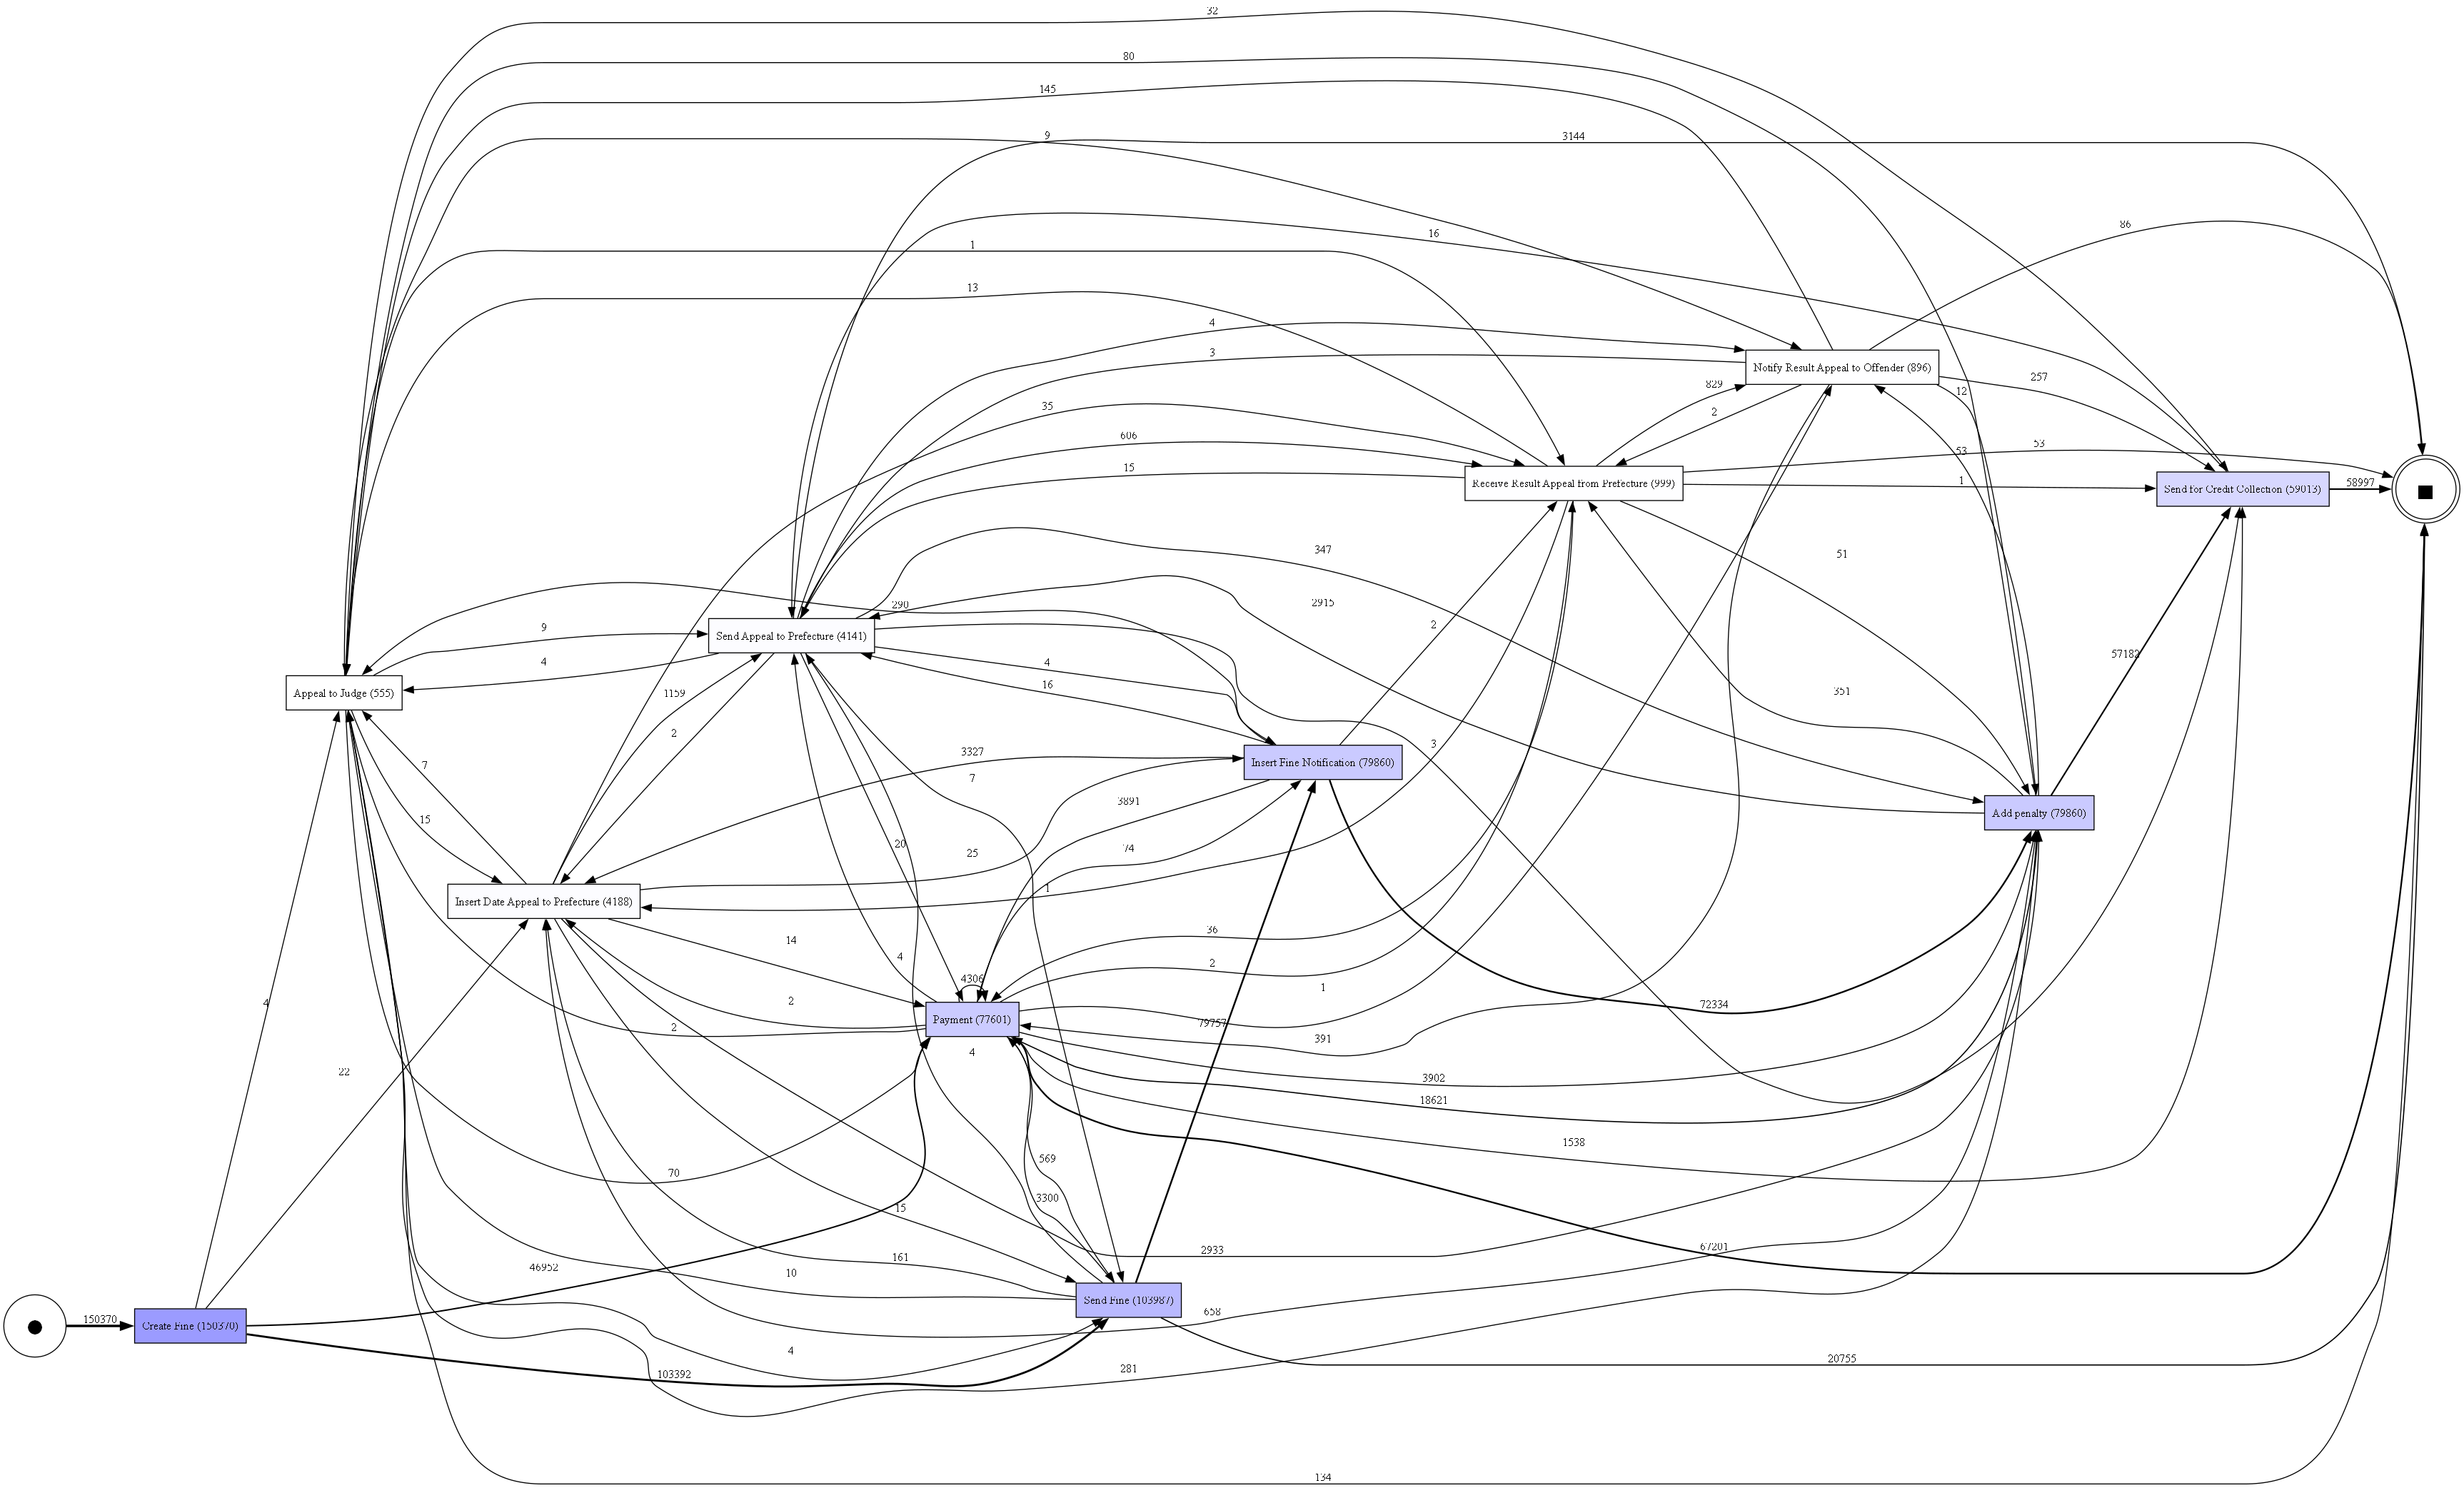

In [122]:
# Discover and display the directly-follows graph for the complete event log.
# Graphviz must be installed and available on the system PATH.

dfg, start_activities, end_activities = pm4py.discover_dfg(log)
pm4py.view_dfg(dfg, start_activities, end_activities)

**Returning to the Dominant Variants**
- The complete process view contains too many paths and connections to provide a useful overview. The participant therefore returns to the variant explorer and restricts attention to the four most frequent variants.
- At this level, the participant finds the process substantially easier to interpret. The top four variants are therefore used as a compact representation of the dominant process behavior during this familiarization stage.


In [123]:
top_4_variants = variants_df.head(4)
display(top_4_variants[["variant_rank", "case_count", "percentage", "variant"]])

print("Cases covered by top 4 variants:", f"{top_4_variants['case_count'].sum():,}")
print("Share of all cases:", f"{top_4_variants['case_count'].sum() / log[CASE_ID_COL].nunique() * 100:.2f}%")

,variant_rank,case_count,percentage,variant
0,1,56482,37.562014,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,46371,30.837933,"(Create Fine, Payment)"
2,3,20385,13.556560,"(Create Fine, Send Fine)"
3,4,9520,6.331050,"(Create Fine, Send Fine, Insert Fine Notificat..."


Cases covered by top 4 variants: 132,758
Share of all cases: 88.29%


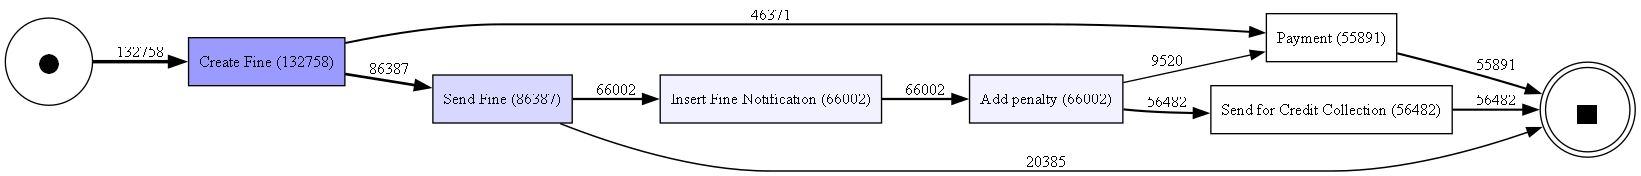

In [124]:
# Determine each case's variant and retain cases belonging to the four dominant variants.

case_variants = log.sort_values([CASE_ID_COL, TIMESTAMP_COL]).groupby(CASE_ID_COL)[ACTIVITY_COL].apply(tuple)
top_4_case_ids = case_variants[case_variants.isin(set(top_4_variants["variant"]))].index
top_4_log = log.loc[log[CASE_ID_COL].isin(top_4_case_ids)].copy()

top_4_dfg, top_4_start, top_4_end = pm4py.discover_dfg(top_4_log)
pm4py.view_dfg(top_4_dfg, top_4_start, top_4_end)

**Exploring the Process at Different Levels of Detail**
- The participant next switches from the Variant Explorer to the Process Explorer and gradually increases the amount of process behavior shown.
- When the visualization includes approximately 98% of the activities, the result reinforces the earlier observation that the process is structurally complex and that a reduced view is more useful for obtaining an overview.
- The Celonis Process Explorer uses its own interactive abstraction controls, we approximate the same analytical action below by progressively retaining more frequent directly-follows relations.

In [125]:
def filter_dfg_by_frequency_coverage(dfg, coverage=0.98):
    sorted_edges = sorted(dfg.items(), key=lambda item: item[1], reverse=True)
    total_frequency, cumulative_frequency, filtered_dfg = sum(dfg.values()), 0, {}

    if total_frequency == 0:
        return filtered_dfg, 0.0

    for edge, frequency in sorted_edges:
        filtered_dfg[edge] = frequency
        cumulative_frequency += frequency
        if cumulative_frequency >= total_frequency * coverage:
            break

    return filtered_dfg, cumulative_frequency / total_frequency

All directly-follows relations: 70
Relations shown: 14
Activities shown: 8
Actual frequency coverage: 98.36%


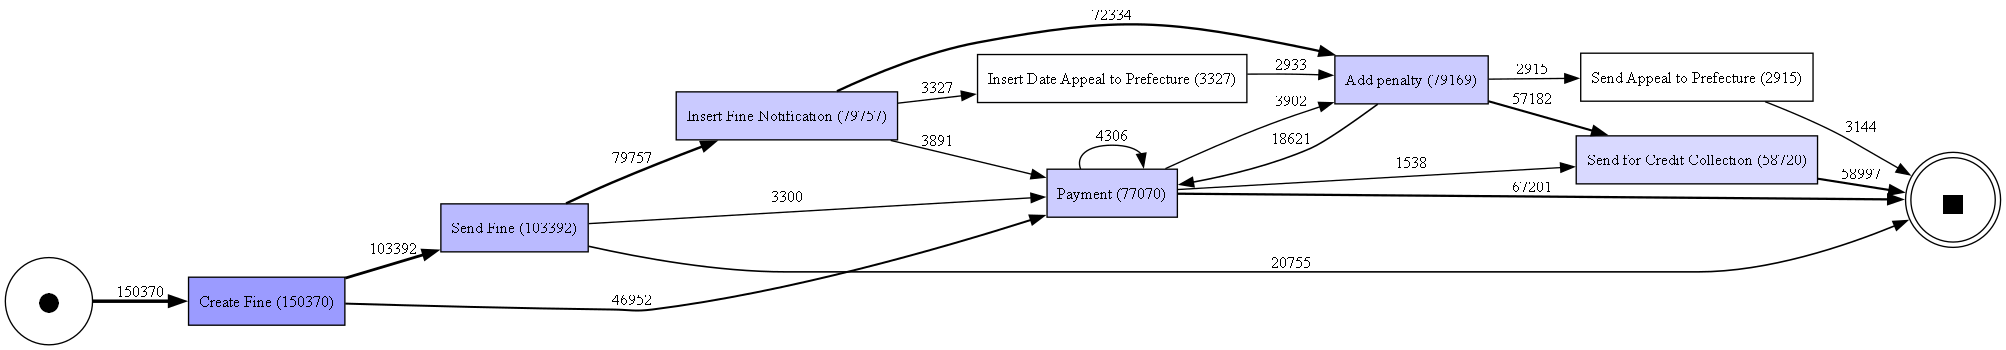

In [126]:
# Discover the complete DFG and retain edges covering approximately 98% of frequency.

dfg, start_activities, end_activities = pm4py.discover_dfg(log)
dfg_98, actual_coverage = filter_dfg_by_frequency_coverage(dfg, coverage=0.98)

included_activities = {activity for edge in dfg_98 for activity in edge}
start_activities_98 = {activity: count for activity, count in start_activities.items() if activity in included_activities}
end_activities_98 = {activity: count for activity, count in end_activities.items() if activity in included_activities}

print(f"All directly-follows relations: {len(dfg)}")
print(f"Relations shown: {len(dfg_98)}")
print(f"Activities shown: {len(included_activities)}")
print(f"Actual frequency coverage: {actual_coverage:.2%}")

pm4py.view_dfg(dfg_98, start_activities_98, end_activities_98)

**Reviewing the Process Context**
- After exploring the process structure, the participant returns to the contextual information provided with the task. They review the activity descriptions to better understand the meaning of the activities appearing in the process maps. They then reread the guiding questions defining the analytical objective.
- At this point, the participant considers the initial familiarization complete. The exploration so far has provided an overview of the dominant process paths and revealed the considerable complexity of the full process, but it has not yet produced an explanation for unpaid fines. The participant now moves to a more focused exploration of the questions.


**Focused Exploration of Unpaid Fines**
- The participant returns to the activity descriptions and identifies Send for Credit Collection as an important indicator of non-payment.
- The activity description states that unpaid fines are sent for credit collection. The participant therefore interprets the occurrence of Send for Credit Collection as an indication that the fine has not been successfully paid through the normal process.


**Revisiting the Dominant Variants**
- With this interpretation in mind, the participant returns to the Variant Explorer. After experimenting with different levels of detail, he again settles on the four most frequent variants.
- He traces the activity sequences of these variants more carefully, now specifically looking for the relationship between Payment and Send for Credit Collection.
- The participant notices that some process paths still contain a payment event. This suggests that the presence of a payment event alone does not necessarily imply that the fine was paid in full.


In [127]:
# Retain cases containing Send for Credit Collection and inspect their variants.

credit_collection_case_ids = set(log.loc[log[ACTIVITY_COL].eq("Send for Credit Collection"), CASE_ID_COL])
credit_collection_log = log.loc[log[CASE_ID_COL].isin(credit_collection_case_ids)].copy()

credit_collection_variants = pm4py.get_variants(credit_collection_log)
credit_collection_variants_df = pd.DataFrame(
    [{"variant": variant, "case_count": count} for variant, count in credit_collection_variants.items()]
).sort_values("case_count", ascending=False).reset_index(drop=True)

credit_collection_variants_df["variant_rank"] = credit_collection_variants_df.index + 1
credit_collection_variants_df["percentage"] = credit_collection_variants_df["case_count"] / credit_collection_variants_df["case_count"].sum() * 100

print("Top four variants among credit-collection cases")
display(credit_collection_variants_df[["variant_rank", "case_count", "percentage", "variant"]].head(4))

# Remove credit-collection cases containing at least one Payment activity.

credit_collection_payment_cases = set(credit_collection_log.loc[credit_collection_log[ACTIVITY_COL].eq("Payment"), CASE_ID_COL])
credit_collection_without_payment_ids = credit_collection_case_ids - credit_collection_payment_cases
credit_collection_without_payment_log = log.loc[log[CASE_ID_COL].isin(credit_collection_without_payment_ids)].copy()

total_cases = log[CASE_ID_COL].nunique()

print(f"Cases containing Send for Credit Collection: {len(credit_collection_case_ids):,} ({len(credit_collection_case_ids) / total_cases:.1%} of all cases)")
print(f"Credit-collection cases without Payment: {len(credit_collection_without_payment_ids):,} ({len(credit_collection_without_payment_ids) / total_cases:.1%} of all cases)")

Top four variants among credit-collection cases


,variant_rank,case_count,percentage,variant
0,1,56482,95.711115,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,1515,2.567231,"(Create Fine, Send Fine, Insert Fine Notificat..."
2,3,522,0.884551,"(Create Fine, Send Fine, Insert Fine Notificat..."
3,4,108,0.183011,"(Create Fine, Send Fine, Insert Fine Notificat..."


Cases containing Send for Credit Collection: 59,013 (39.2% of all cases)
Credit-collection cases without Payment: 56,887 (37.8% of all cases)


In [128]:
credit_no_payment_variants = pm4py.get_variants(credit_collection_without_payment_log)
credit_no_payment_variants_df = pd.DataFrame(
    [{"variant": variant, "case_count": count} for variant, count in credit_no_payment_variants.items()]
).sort_values("case_count", ascending=False).reset_index(drop=True)

credit_no_payment_variants_df["variant_rank"] = credit_no_payment_variants_df.index + 1
credit_no_payment_variants_df["percentage"] = credit_no_payment_variants_df["case_count"] / credit_no_payment_variants_df["case_count"].sum() * 100

variant_columns = ["variant_rank", "case_count", "percentage", "variant"]

print("Top four variants after removing Payment cases")
display(credit_no_payment_variants_df[variant_columns].head(4))

print("Most common variant")
display(credit_no_payment_variants_df[variant_columns].head(1))

Top four variants after removing Payment cases


,variant_rank,case_count,percentage,variant
0,1,56482,99.288062,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,108,0.189850,"(Create Fine, Send Fine, Insert Fine Notificat..."
2,3,88,0.154693,"(Create Fine, Send Fine, Insert Fine Notificat..."
3,4,81,0.142388,"(Create Fine, Send Fine, Insert Fine Notificat..."


Most common variant


,variant_rank,case_count,percentage,variant
0,1,56482,99.288062,"(Create Fine, Send Fine, Insert Fine Notificat..."


**Filtering Credit-Collection Cases Without Payment**

- The participant filters the log to cases containing *Send for Credit Collection*, resulting in 59,013 cases.
- He inspects the four most frequent variants in this subset.
- He then removes cases containing a *Payment* activity, leaving 56,887 cases, approximately 56.9 thousand.
- Within the reduced subset, he inspects the four most frequent variants again and then the most common variant.

**Inspecting Case Attributes**
- The participant briefly opens an OLAP table and reviews the available case attributes together with their descriptions.
- He then concludes that he has sufficient understanding of the data for the moment and returns to the process-oriented analysis.


In [129]:
# Create one row per case using the last non-null value of each attribute.
# Values may originate from different events within the same case.

case_attributes = credit_collection_without_payment_log.sort_values(
    [CASE_ID_COL, TIMESTAMP_COL]
).groupby(CASE_ID_COL).last().reset_index()

case_attributes.head()

,Case ID,Activity,Resource,Complete Timestamp,Variant,Variant index,amount,article,dismissal,expense,...,paymentAmount,points,totalPaymentAmount,vehicleClass,case:concept:name,concept:name,time:timestamp,@@index,@@case_index,start_timestamp
0,A100,Send for Credit Collection,561,2009-03-30 00:00:00+00:00,Variant 1,1,71.5,157.0,NIL,11.0,...,NaN,0.0,0.0,A,A100,Send for Credit Collection,2009-03-30 00:00:00+00:00,6,1,2009-03-30 00:00:00+00:00
1,A10004,Send for Credit Collection,537,2009-03-30 00:00:00+00:00,Variant 1,1,74.0,157.0,NIL,13.0,...,NaN,0.0,0.0,A,A10004,Send for Credit Collection,2009-03-30 00:00:00+00:00,22,4,2009-03-30 00:00:00+00:00
2,A10008,Send for Credit Collection,537,2009-03-30 00:00:00+00:00,Variant 1,1,74.0,157.0,NIL,13.0,...,NaN,0.0,0.0,A,A10008,Send for Credit Collection,2009-03-30 00:00:00+00:00,31,7,2009-03-30 00:00:00+00:00
3,A1001,Send for Credit Collection,550,2009-03-30 00:00:00+00:00,Variant 1,1,42.5,7.0,NIL,11.0,...,NaN,0.0,0.0,A,A1001,Send for Credit Collection,2009-03-30 00:00:00+00:00,42,9,2009-03-30 00:00:00+00:00
4,A10010,Send for Credit Collection,537,2009-03-30 00:00:00+00:00,Variant 1,1,74.0,157.0,NIL,13.0,...,NaN,0.0,0.0,A,A10010,Send for Credit Collection,2009-03-30 00:00:00+00:00,47,10,2009-03-30 00:00:00+00:00


In [130]:
case_attributes.columns.tolist()

['Case ID',
 'Activity',
 'Resource',
 'Complete Timestamp',
 'Variant',
 'Variant index',
 'amount',
 'article',
 'dismissal',
 'expense',
 'lastSent',
 'lifecycle:transition',
 'matricola',
 'notificationType',
 'paymentAmount',
 'points',
 'totalPaymentAmount',
 'vehicleClass',
 'case:concept:name',
 'concept:name',
 'time:timestamp',
 '@@index',
 '@@case_index',
 'start_timestamp']

In [131]:
candidate_attributes = [
    CASE_ID_COL,
    "amount",
    "totalPaymentAmount",
    "dismissal",
    "article",
    "expense",
    "notificationType",
    "points",
    "vehicleClass"
]

available_attributes = [
    col for col in candidate_attributes
    if col in case_attributes.columns
]

case_attributes[available_attributes].head(20)

,Case ID,amount,totalPaymentAmount,dismissal,article,expense,notificationType,points,vehicleClass
0,A100,71.5,0.0,NIL,157.0,11.0,P,0.0,A
1,A10004,74.0,0.0,NIL,157.0,13.0,P,0.0,A
2,A10008,74.0,0.0,NIL,157.0,13.0,P,0.0,A
3,A1001,42.5,0.0,NIL,7.0,11.0,P,0.0,A
4,A10010,74.0,0.0,NIL,157.0,13.0,P,0.0,A
5,A10011,74.0,0.0,NIL,157.0,18.6,P,0.0,A
6,A10015,74.0,0.0,NIL,157.0,13.0,P,0.0,A
7,A10019,74.0,0.0,NIL,157.0,13.0,P,0.0,A
8,A1002,42.5,0.0,NIL,7.0,11.0,P,0.0,A
9,A10021,74.0,0.0,NIL,157.0,13.0,P,0.0,A


<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 2: Cases Without Payment

The analyst filtered the full log to cases containing `Send for Credit Collection`, viewed their top 4 variants, removed cases containing `Payment`, and then viewed the top 4 and most common remaining variants.

The FilterBranchMap reproduces this sequence and exposes its complementary branches. Credit-collection cases are almost never fully paid, particularly when no `Payment` activity is recorded. The complements also show that some cases contain a payment without being fully paid.

</div>

In [132]:
# FilterBranchMap 2: Cases without payment

branch2_log, branch2_view = branchmap_log, branchmap_view

credit_collection_ids = set(branch2_log.loc[branch2_log[ACTIVITY].eq("Send for Credit Collection"), CASE_ID])
payment_ids = set(branch2_log.loc[branch2_log[ACTIVITY].eq("Payment"), CASE_ID])
credit_collection_without_payment_ids = credit_collection_ids - payment_ids

credit_collection_variants, credit_collection_variant_counts = add_subset_variant_rank(branch2_log, credit_collection_ids, "credit_collection_variant_rank")
credit_no_payment_variants, credit_no_payment_variant_counts = add_subset_variant_rank(branch2_log, credit_collection_without_payment_ids, "credit_no_payment_variant_rank")

query_full_log_credit_collection = Query("FullLog_ContainsCreditCollection", [EventAttributeValues(ACTIVITY, "Send for Credit Collection")])
query_credit_collection_top4 = Query("CreditCollection_Top4Variants", [LessEqualToConstant("credit_collection_variant_rank", 4)])
query_credit_collection_without_payment = Query("CreditCollection_WithoutPayment", [NotEqToConstant(ACTIVITY, "Payment")])
query_credit_no_payment_top4 = Query("CreditCollectionWithoutPayment_Top4Variants", [LessEqualToConstant("credit_no_payment_variant_rank", 4)])
query_credit_no_payment_top1 = Query("CreditCollectionWithoutPayment_Top1Variant", [LessEqualToConstant("credit_no_payment_variant_rank", 1)])

branch2_filters = [query_full_log_credit_collection, query_credit_collection_top4, query_credit_collection_without_payment, query_credit_no_payment_top4, query_credit_no_payment_top1]
branch2_selected_sublogs = show_branchmap(branch2_view, branch2_log, branch2_filters)

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 2: Cases Without Payment, Excluding Variant Views

The original analysis includes several changes to the number of variants displayed. In this simplified map, we do not treat those views as substantive case filters and therefore leave them out.

The map retains the two central case restrictions: cases must contain `Send for Credit Collection` and must not contain a `Payment` activity. The complementary branches show cases without credit collection and credit-collection cases that contain a payment.

</div>

In [ ]:
# Simplified FilterBranchMap 2: variant views are excluded.

branch2_without_variants_filters = [query_full_log_credit_collection.name, query_credit_collection_without_payment.name]
branch2_without_variants_selected_sublogs = filterbranchmap(
    branch2_view, result_set_name=None, source_log=branch2_log, filters=branch2_without_variants_filters,
    metric="paid_percentage", custom_metrics=BRANCHMAP_METRICS,
    allow_filter_selection=True, allow_reordering=True, allow_subset_saving=True
)

**Constructing a Reference Model for Conformance Checking**
- The participant next attempts a conformance analysis. However, the initially available process model is not considered an appropriate representation of the desired process.
- He therefore constructs a reference model from cases that appear to represent successful payment behavior.
- To approximate a desirable process outcome, the participant selects cases that:
    * contain a Payment activity; and
    * do not contain Send for Credit Collection.
- Among these cases, the six most frequent process variants are selected. In Celonis, these variants are exported as a BPMN model and subsequently used as the reference model in the Conformance Checker.

In [134]:
all_case_ids = set(log[CASE_ID_COL].unique())
cases_with_payment = set(log.loc[log[ACTIVITY_COL].eq("Payment"), CASE_ID_COL])
cases_with_credit_collection = set(log.loc[log[ACTIVITY_COL].eq("Send for Credit Collection"), CASE_ID_COL])
desired_case_ids = cases_with_payment - cases_with_credit_collection
desired_log = log.loc[log[CASE_ID_COL].isin(desired_case_ids)].copy()

print(f"Candidate desired cases: {len(desired_case_ids):,}")

Candidate desired cases: 67,589


In [135]:
desired_variants = pm4py.get_variants(desired_log)
desired_variants_df = pd.DataFrame([{"variant": variant, "case_count": count} for variant, count in desired_variants.items()])
desired_variants_df = desired_variants_df.sort_values("case_count", ascending=False).reset_index(drop=True)
desired_variants_df["variant_rank"] = desired_variants_df.index + 1
desired_variants_df["percentage"] = desired_variants_df["case_count"] / desired_variants_df["case_count"].sum() * 100

desired_variants_df.head(6)

,variant,case_count,variant_rank,percentage
0,"(Create Fine, Payment)",46371,1,68.607318
1,"(Create Fine, Send Fine, Insert Fine Notificat...",9520,2,14.085132
2,"(Create Fine, Send Fine, Insert Fine Notificat...",3736,3,5.527527
3,"(Create Fine, Send Fine, Insert Fine Notificat...",3301,4,4.883931
4,"(Create Fine, Send Fine, Payment)",3131,5,4.632411
5,"(Create Fine, Payment, Send Fine)",362,6,0.535590


In [136]:
# Determine each desired case's activity sequence and retain the six leading variants.

desired_case_variants = desired_log.sort_values([CASE_ID_COL, TIMESTAMP_COL]).groupby(CASE_ID_COL)[ACTIVITY_COL].apply(tuple)
top_6_desired_variants = set(desired_variants_df.head(6)["variant"])
reference_case_ids = desired_case_variants[desired_case_variants.isin(top_6_desired_variants)].index
reference_log = desired_log.loc[desired_log[CASE_ID_COL].isin(reference_case_ids)].copy()

print(f"Cases represented by the six reference variants: {len(reference_case_ids):,}")

Cases represented by the six reference variants: 66,421


<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 3: Successful-Payment Subset

The analyst constructs a reference model from cases without `Send for Credit Collection` that contain at least one `Payment`. He then selects the six most frequent variants within this subset.

This map uses the complementary outcomes of the main filters from Branch 2 in reverse order. It therefore presents the same central case distinction from the successful-payment perspective. The top-six variant filter reproduces the analyst’s final selection for the reference model.

</div>

In [137]:
# FilterBranchMap 3: Successful-payment subset

branch3_log, branch3_view = branchmap_log, branchmap_view

branch3_payment_ids = set(branch3_log.loc[branch3_log[ACTIVITY].eq("Payment"), CASE_ID])
branch3_credit_collection_ids = set(branch3_log.loc[branch3_log[ACTIVITY].eq("Send for Credit Collection"), CASE_ID])
branch3_reference_ids = branch3_payment_ids - branch3_credit_collection_ids
branch3_case_variants, branch3_variant_counts = add_subset_variant_rank(branch3_log, branch3_reference_ids, "successful_payment_variant_rank")

query_full_log_without_credit_collection = Query("FullLog_WithoutCreditCollection", [NotEqToConstant(ACTIVITY, "Send for Credit Collection")])
query_without_credit_collection_with_payment = Query("WithoutCreditCollection_WithPayment", [EventAttributeValues(ACTIVITY, "Payment")])
query_successful_payment_top6 = Query("WithoutCreditCollectionWithPayment_Top6Variants", [LessEqualToConstant("successful_payment_variant_rank", 6)])

branch3_filters = [query_full_log_without_credit_collection, query_without_credit_collection_with_payment, query_successful_payment_top6]
branch3_selected_sublogs = show_branchmap(branch3_view, branch3_log, branch3_filters)

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 3: Successful-Payment Subset, Excluding Variant Views

The original analysis selects the six most frequent variants when constructing the reference model. In this simplified map, we do not treat the number of displayed variants as a substantive case filter and therefore leave that filter out.

The map retains the two central restrictions: cases must not contain `Send for Credit Collection` and must contain at least one `Payment`. This isolates the successful-payment subset while preserving the complementary branches.

</div>

In [ ]:
# Simplified FilterBranchMap 3: variant selection is excluded.

branch3_without_variants_filters = [query_full_log_without_credit_collection.name, query_without_credit_collection_with_payment.name]
branch3_without_variants_selected_sublogs = filterbranchmap(
    branch3_view, result_set_name=None, source_log=branch3_log, filters=branch3_without_variants_filters,
    metric="paid_percentage", custom_metrics=BRANCHMAP_METRICS,
    allow_filter_selection=True, allow_reordering=True, allow_subset_saving=True
)

**Discovering the Reference Process Model**
- In Celonis, the participant exports the six selected variants as BPMN and uploads this model into the Conformance Checker.
- In the notebook, a process model is discovered from the cases belonging to the six selected variants and is subsequently used as the reference against which the complete event log is evaluated.


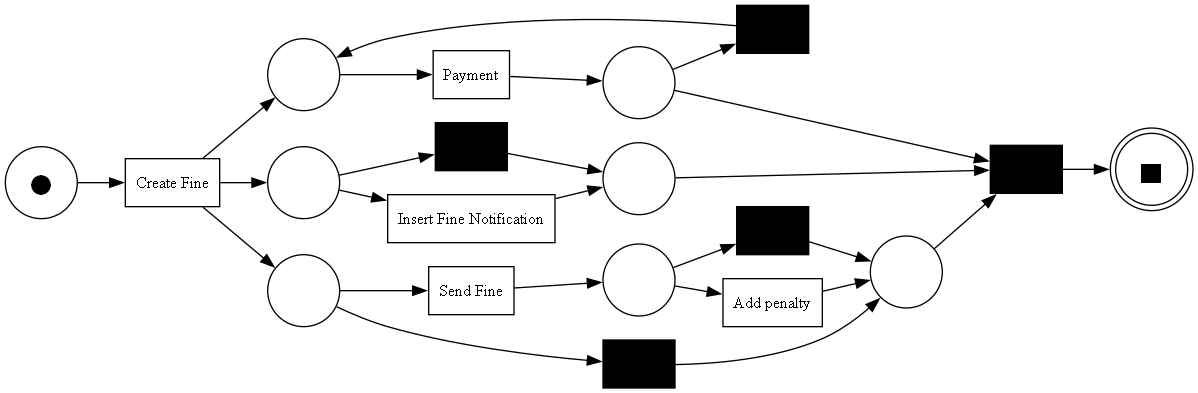

In [139]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(reference_log)
pm4py.view_petri_net(net, initial_marking, final_marking)

In [140]:
alignment_results = pm4py.conformance_diagnostics_alignments(log, net, initial_marking, final_marking)
case_ids = log.sort_values([CASE_ID_COL, TIMESTAMP_COL]).groupby(CASE_ID_COL).size().index
conformance_df = pd.DataFrame({"case_id": case_ids, "fitness": [result.get("fitness") for result in alignment_results]})

conformance_df.head()

aligning log, completed variants ::   0%|          | 0/231 [00:00<?, ?it/s]

,case_id,fitness
0,A1,0.750000
1,A100,0.714286
2,A10000,1.000000
3,A10001,0.625000
4,A10004,0.714286


In [141]:
conformance_df["conforming"] = conformance_df["fitness"].ge(0.999999)
conformance_summary = conformance_df["conforming"].value_counts().rename(index={True: "Conforming", False: "Non-conforming"})

display(conformance_summary)
print(f"Conforming: {conformance_df['conforming'].mean():.1%}")
print(f"Non-conforming: {(~conformance_df['conforming']).mean():.1%}")

conforming
Non-conforming    83550
Conforming        66820
Name: count, dtype: int64

Conforming: 44.4%
Non-conforming: 55.6%


**Conformance Results**
- Approximately 44% of cases were classified as conforming, while approximately 56% were classified as non-conforming.
- The participant then examines the deviations occurring among the non-conforming cases. The most prominent first undesired activity is Send for Credit Collection, occurring in approximately 39% of cases.
- This confirms that credit collection represents a deviation from the constructed desirable process and motivates a more detailed investigation of these cases.


In [142]:
nonconforming_case_ids = set(conformance_df.loc[~conformance_df["conforming"], "case_id"])
credit_collection_case_ids = set(log.loc[log[ACTIVITY_COL].eq("Send for Credit Collection"), CASE_ID_COL])
nonconforming_credit_cases = nonconforming_case_ids & credit_collection_case_ids

print(f"Non-conforming cases containing Send for Credit Collection: {len(nonconforming_credit_cases):,}")
print(f"Share of all cases: {len(nonconforming_credit_cases) / total_cases:.1%}")

Non-conforming cases containing Send for Credit Collection: 59,013
Share of all cases: 39.2%


**Attempting to Explain the Conformance Deviation**
- Because Send for Credit Collection is the dominant undesirable behavior, the participant drills down into these cases and performs a root-cause analysis.
- Several attributes that are unlikely to provide explanatory value are removed from the analysis, including the activity name, timestamp, amount, and the Celonis change date.
- The Celonis root-cause analysis identifies three prominent candidate variables:
    1. the process variant;
    2. the variant index; and
    3. `totalPaymentAmount`.
- The participant does not consider these findings satisfactory explanations. The variant and variant index largely describe the process behavior itself rather than explaining why it occurred, while the payment amount does not provide a convincing cause.
- The participant therefore concludes that this root-cause analysis does not yet reveal a meaningful reason for the fines being sent to credit collection.


**Approximation of the Root-Cause Analysis**

The original root-cause analysis was performed in Celonis. The following tables reproduce the variables highlighted during that analysis—process variant, variant index, and `totalPaymentAmount`—but do not reproduce Celonis's proprietary variable-ranking algorithm. They should therefore be interpreted as a reconstruction of the inspected results rather than an independent replication of the root-cause calculation.

In [143]:
case_level = log.sort_values([CASE_ID_COL, TIMESTAMP_COL]).groupby(CASE_ID_COL).last().reset_index()
case_level["credit_collection"] = case_level[CASE_ID_COL].isin(credit_collection_case_ids)

case_variant_series = log.sort_values([CASE_ID_COL, TIMESTAMP_COL]).groupby(CASE_ID_COL)[ACTIVITY_COL].apply(tuple)
case_level = case_level.merge(case_variant_series.rename("variant"), left_on=CASE_ID_COL, right_index=True, how="left")

variant_rank_lookup = dict(zip(variants_df["variant"], variants_df["variant_rank"]))
case_level["variant_index"] = case_level["variant"].map(variant_rank_lookup)

root_cause_columns = [CASE_ID_COL, "credit_collection", "variant", "variant_index", "totalPaymentAmount"]
available_root_cause_columns = [column for column in root_cause_columns if column in case_level.columns]

case_level[available_root_cause_columns].head(20)

,Case ID,credit_collection,variant,variant_index,totalPaymentAmount
0,A1,False,"(Create Fine, Send Fine)",3,0.0
1,A100,True,"(Create Fine, Send Fine, Insert Fine Notificat...",1,0.0
2,A10000,False,"(Create Fine, Send Fine, Insert Fine Notificat...",4,87.0
3,A10001,False,"(Create Fine, Send Fine, Insert Fine Notificat...",8,0.0
4,A10004,True,"(Create Fine, Send Fine, Insert Fine Notificat...",1,0.0
5,A10005,False,"(Create Fine, Payment)",2,36.0
6,A10007,False,"(Create Fine, Payment)",2,36.0
7,A10008,True,"(Create Fine, Send Fine, Insert Fine Notificat...",1,0.0
8,A10009,False,"(Create Fine, Send Fine, Insert Fine Notificat...",5,57.0
9,A1001,True,"(Create Fine, Send Fine, Insert Fine Notificat...",1,0.0


In [144]:
case_level.groupby("credit_collection")["totalPaymentAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
credit_collection,,,,,,,,
False,91357.0,38.178502,45.226763,0.0,0.0,35.0,39.51,4021.0
True,59013.0,1.963771,12.795026,0.0,0.0,0.0,0.00,727.0


In [145]:
case_level.groupby("credit_collection")["variant_index"].describe()

,count,mean,std,min,25%,50%,75%,max
credit_collection,,,,,,,,
False,91357.0,3.790087,7.537234,2.0,2.0,2.0,4.0,231.0
True,59013.0,1.573484,4.703661,1.0,1.0,1.0,1.0,229.0


In [146]:
case_level.loc[case_level["credit_collection"], "variant"].value_counts().head(10)

variant
(Create Fine, Send Fine, Insert Fine Notification, Add penalty, Send for Credit Collection)                                                                                                                                          56482
(Create Fine, Send Fine, Insert Fine Notification, Add penalty, Payment, Send for Credit Collection)                                                                                                                                  1515
(Create Fine, Send Fine, Insert Fine Notification, Payment, Add penalty, Send for Credit Collection)                                                                                                                                   522
(Create Fine, Send Fine, Insert Fine Notification, Appeal to Judge, Add penalty, Send for Credit Collection)                                                                                                                           108
(Create Fine, Send Fine, Insert Fine Notification, I

**No Explanatory Root Cause Identified**
- The root-cause attempt is considered unsuccessful. The researcher notes that the study task does not require every situation to have a causal explanation: identifying recurring situations or circumstances in which fines are not paid is itself a valid outcome.
- The participant therefore shifts attention away from root-cause analysis and returns to the process behavior of the credit-collection cases in order to identify more specific circumstances.
- The participant first inspects the four most frequent variants within this subset and then expands the view to the seven most frequent variants. The aim is to identify recurring process situations that could explain why payment was not completed.

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 4: Non-Conforming Credit-Collection Cases

The analyst examines the non-conforming cases and identifies `Send for Credit Collection` as the most common undesired activity. He then attempts a root-cause analysis but does not find a satisfactory explanation.

The FilterBranchMap shows how frequently credit collection occurs within the non-conforming subset. Its complementary branches also show that conforming cases do not contain this activity and have a substantially higher full-payment rate, supporting the analyst’s interpretation.

</div>

In [147]:
# FilterBranchMap 4: Non-conforming credit-collection cases

branch4_log, branch4_view = branchmap_log, branchmap_view

branch4_conformance_status = conformance_df.drop_duplicates("case_id").set_index("case_id")["conforming"].map({True: "Conforming", False: "NonConforming"})
branch4_log["conformance_status"] = branch4_log[CASE_ID].map(branch4_conformance_status)

query_full_log_nonconforming = Query("FullLog_NonConformingCases", [EqToConstant("conformance_status", "NonConforming")])
query_nonconforming_credit_collection = Query("NonConforming_ContainsCreditCollection", [EventAttributeValues(ACTIVITY, "Send for Credit Collection")])

branch4_filters = [query_full_log_nonconforming, query_nonconforming_credit_collection]
branch4_selected_sublogs = show_branchmap(branch4_view, branch4_log, branch4_filters)

c:\Users\laura\Downloads\FilterBranchMap-main\FilterBranchMap-main\logview\log_view.py:68: UserWarning: Ignoring the new name 'rs_NonConforming_ContainsCreditCollection' since you are getting back an already computed result set with name rs_FullLog_ContainsCreditCollection
  warnings.warn(msg)


<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 4: Credit-Collection Cases, Excluding Conformance

The original analysis first selects non-conforming cases and then examines those containing `Send for Credit Collection`. In this simplified map, we leave out the conformance filter for the same reason that variant filters were omitted earlier: it represents an analytical classification or view rather than a direct condition in the original event data.

The map therefore retains only `Send for Credit Collection`, the process condition central to this part of the analysis. Its complement shows cases that were not transferred to credit collection.

</div>

In [ ]:
# Simplified FilterBranchMap 4: conformance is excluded.

branch4_without_conformance_filters = [query_nonconforming_credit_collection.name]
branch4_without_conformance_selected_sublogs = filterbranchmap(
    branch4_view, result_set_name=None, source_log=branch4_log, filters=branch4_without_conformance_filters,
    metric="paid_percentage", custom_metrics=BRANCHMAP_METRICS,
    allow_filter_selection=True, allow_reordering=True, allow_subset_saving=True
)

In [149]:
# Restrict the log to non-conforming credit-collection cases and extract their variants.

credit_violation_log = log.loc[log[CASE_ID_COL].isin(nonconforming_credit_cases)].copy()
credit_violation_variants = pm4py.get_variants(credit_violation_log)

credit_violation_variants_df = pd.DataFrame(
    [{"variant": variant, "case_count": count} for variant, count in credit_violation_variants.items()]
).sort_values("case_count", ascending=False).reset_index(drop=True)

credit_violation_variants_df["variant_rank"] = credit_violation_variants_df.index + 1
credit_violation_variants_df["percentage"] = credit_violation_variants_df["case_count"] / credit_violation_variants_df["case_count"].sum() * 100

credit_violation_variants_df.head(4)

,variant,case_count,variant_rank,percentage
0,"(Create Fine, Send Fine, Insert Fine Notificat...",56482,1,95.711115
1,"(Create Fine, Send Fine, Insert Fine Notificat...",1515,2,2.567231
2,"(Create Fine, Send Fine, Insert Fine Notificat...",522,3,0.884551
3,"(Create Fine, Send Fine, Insert Fine Notificat...",108,4,0.183011


In [150]:
# Reproduce the analyst's top 4, top 5, and top 7 views.

variant_columns = ["variant_rank", "case_count", "percentage", "variant"]

for n in [4, 5, 7]:
    print(f"\nTop {n} credit-collection variants")
    display(credit_violation_variants_df[variant_columns].head(n))


Top 4 credit-collection variants


,variant_rank,case_count,percentage,variant
0,1,56482,95.711115,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,1515,2.567231,"(Create Fine, Send Fine, Insert Fine Notificat..."
2,3,522,0.884551,"(Create Fine, Send Fine, Insert Fine Notificat..."
3,4,108,0.183011,"(Create Fine, Send Fine, Insert Fine Notificat..."



Top 5 credit-collection variants


,variant_rank,case_count,percentage,variant
0,1,56482,95.711115,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,1515,2.567231,"(Create Fine, Send Fine, Insert Fine Notificat..."
2,3,522,0.884551,"(Create Fine, Send Fine, Insert Fine Notificat..."
3,4,108,0.183011,"(Create Fine, Send Fine, Insert Fine Notificat..."
4,5,88,0.149120,"(Create Fine, Send Fine, Insert Fine Notificat..."



Top 7 credit-collection variants


,variant_rank,case_count,percentage,variant
0,1,56482,95.711115,"(Create Fine, Send Fine, Insert Fine Notificat..."
1,2,1515,2.567231,"(Create Fine, Send Fine, Insert Fine Notificat..."
2,3,522,0.884551,"(Create Fine, Send Fine, Insert Fine Notificat..."
3,4,108,0.183011,"(Create Fine, Send Fine, Insert Fine Notificat..."
4,5,88,0.149120,"(Create Fine, Send Fine, Insert Fine Notificat..."
5,6,81,0.137258,"(Create Fine, Send Fine, Insert Fine Notificat..."
6,7,49,0.083033,"(Create Fine, Send Fine, Insert Fine Notificat..."


<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 5: Credit-Collection Variants

The analyst filters for cases containing `Send for Credit Collection` and then views the top 4, top 5, and top 7 variants. These variant selections were calculated independently within the credit-collection subset.

For demonstration, the FilterBranchMap places them in the analyst’s viewing order: **top 4 → top 5 → top 7**. The leading variants already contain almost all credit-collection cases, so the differences between these selections are small and the map adds limited new information.

</div>

In [151]:
# FilterBranchMap 5: Credit-collection variants

branch5_log, branch5_view = branchmap_log, branchmap_view

# Reuse the credit-collection subset, ranking, and filters from Branch 2.
branch5_credit_collection_ids = credit_collection_ids
branch5_case_variants, branch5_variant_counts = credit_collection_variants, credit_collection_variant_counts
query_full_log_credit_collection_b5 = query_full_log_credit_collection
query_credit_collection_top4_b5 = query_credit_collection_top4

# Add only the new Branch 5 filters.
query_credit_collection_top5_b5 = Query("CreditCollection_Top5Variants", [LessEqualToConstant("credit_collection_variant_rank", 5)])
query_credit_collection_top7_b5 = Query("CreditCollection_Top7Variants", [LessEqualToConstant("credit_collection_variant_rank", 7)])

branch5_filters = [query_full_log_credit_collection_b5, query_credit_collection_top4_b5, query_credit_collection_top5_b5, query_credit_collection_top7_b5]

# Register only the new filters, then render the map.
register_branchmap_filters(branch5_view, branch5_log, [query_credit_collection_top5_b5, query_credit_collection_top7_b5])

branch5_selected_sublogs = filterbranchmap(
    branch5_view, result_set_name=None, source_log=branch5_log, filters=branch5_filters,
    metric="paid_percentage", custom_metrics=BRANCHMAP_METRICS,
    allow_filter_selection=True, allow_reordering=True, allow_subset_saving=True
)

**Revisiting the Temporal Constraints**
- After inspecting the dominant variants, the participant returns to the temporal constraints provided with the task.
- The first legal constraint states that the fine notification must occur within 90 days after creation of the fine. If this deadline is violated, the offender is no longer obliged to pay.
- During the actual analysis, however, the participant operationalizes this condition using the sequence *Create Fine → Send Fine* and subsequently applies a threshold of *87 days* rather than the stated 90-day threshold.


In [152]:
def time_between_activities(event_log, first_activity, second_activity):
    """Calculate the time from the first activity to its first subsequent second activity in each case."""

    results = []
    sort_columns = [CASE_ID_COL, TIMESTAMP_COL] + (["@@index"] if "@@index" in event_log.columns else [])
    ordered_log = event_log.sort_values(sort_columns, kind="stable")

    for case_id, case in ordered_log.groupby(CASE_ID_COL, sort=False):
        case = case.reset_index(drop=True)
        first_position = next((i for i, activity in enumerate(case[ACTIVITY_COL]) if activity == first_activity), None)

        if first_position is None:
            continue

        second_position = next((i for i in range(first_position + 1, len(case)) if case.loc[i, ACTIVITY_COL] == second_activity), None)

        if second_position is None:
            continue

        first_time, second_time = case.loc[first_position, TIMESTAMP_COL], case.loc[second_position, TIMESTAMP_COL]
        results.append({
            CASE_ID_COL: case_id, "first_activity": first_activity, "second_activity": second_activity,
            "first_timestamp": first_time, "second_timestamp": second_time,
            "days_between": (second_time - first_time).total_seconds() / 86400
        })

    return pd.DataFrame(results)

In [153]:
# Start this sequence from the complete event log.

create_to_send = time_between_activities(log, "Create Fine", "Send Fine")
cases_create_then_send = set(create_to_send[CASE_ID_COL])
total_cases = log[CASE_ID_COL].nunique()

print(f"Create Fine followed by Send Fine: {len(cases_create_then_send):,} cases")
print(f"Share of all cases: {len(cases_create_then_send) / total_cases:.1%}")

Create Fine followed by Send Fine: 103,987 cases
Share of all cases: 69.2%


In [154]:
delayed_send = create_to_send.loc[create_to_send["days_between"].gt(87)].copy()
delayed_send_case_ids = set(delayed_send[CASE_ID_COL])

print(f"Cases with more than 87 days between Create Fine and Send Fine: {len(delayed_send_case_ids):,}")
print(f"Share of all cases: {len(delayed_send_case_ids) / total_cases:.1%}")

Cases with more than 87 days between Create Fine and Send Fine: 52,026
Share of all cases: 34.6%


**Circumstance 1: Delayed Sending of the Fine**
- The participant identifies a first potentially meaningful situation by examining the time between the creation and sending of the fine.
- Cases are selected in which more than 87 days pass between Create Fine and Send Fine.
- This is interpreted by the participant in relation to the legal notification deadline: when notification occurs too late, the offender may no longer be obliged to pay the fine.
- This provides the first circumstance in which non-payment can potentially be explained by the offender being legally released from the payment obligation.

**Cases identified in the Python reconstruction:** `52,026`  
**Share of the complete event log:** `34.6%`

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 6: Delayed Sending of the Fine

The analyst selects cases where `Create Fine` is eventually followed by `Send Fine`, then retains cases where more than 87 days elapsed between the activities.

The map confirms that cases above the threshold are rarely fully paid. However, cases below the threshold also have a low full-payment rate. The stronger distinction is whether `Create Fine` is followed by `Send Fine`; its complement contains many immediately paid cases. The analyst did not identify this pattern during the original analysis.

</div>

In [155]:
# FilterBranchMap 6: Delayed sending of the fine

branch6_log, branch6_view = branchmap_log, branchmap_view

branch6_days_by_case = create_to_send.set_index("Case ID")["days_between"]
branch6_log["create_to_send_days"] = branch6_log[CASE_ID].map(branch6_days_by_case)

query_full_log_create_to_send = Query("FullLog_CreateFineEventuallySendFine", [EventuallyFollowsRelation([("Create Fine", "Send Fine")])])
query_create_to_send_over_87 = Query("CreateFineToSendFine_MoreThan87Days", [GreaterThanConstant("create_to_send_days", 87)])

branch6_filters = [query_full_log_create_to_send, query_create_to_send_over_87]
branch6_selected_sublogs = show_branchmap(branch6_view, branch6_log, branch6_filters)

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap Side Branch: Reordering After Sequence 6

This extension reorders the filters as `Create Fine → Send Fine`, more than 87 days, and `Send for Credit Collection`. The complements isolate immediate-payment cases, cases below the threshold, and cases not sent for collection.

The full-payment view shows that approximately one-third of cases are fully paid. Among the remaining two-thirds, about 97% are not fully paid. The average-outstanding-payment view shows that the 87-day threshold does not determine whether credit collection occurs.

Two subsets below the threshold are compared using directly-follows graphs:

* **Credit collection:** 31,557 cases and 1,053 `Payment` events.
* **No credit collection:** 20,404 cases and 14,468 `Payment` events.

Finally, adding `Payment` isolates unpaid cases that were not sent for collection. These cases may not have been pursued because collection was not cost-effective, but the data does not confirm this hypothesis.

</div>


In [ ]:
# FilterBranchMap side branch: Reordering after sequence 6

sidebranch6_log, sidebranch6_view = branch6_log, branch6_view
query_sidebranch6_create_to_send, query_sidebranch6_over_87_days = query_full_log_create_to_send, query_create_to_send_over_87
query_sidebranch6_credit_collection = Query("CreateFineToSendFine_ContainsCreditCollection", [EventAttributeValues(ACTIVITY, "Send for Credit Collection")])
query_sidebranch6_with_payment = Query("CreditCollectionComparison_WithPayment", [EventAttributeValues(ACTIVITY, "Payment")])

sidebranch6_filter_queries = [query_sidebranch6_create_to_send, query_sidebranch6_over_87_days, query_sidebranch6_credit_collection]
sidebranch6_extended_filter_queries = [*sidebranch6_filter_queries, query_sidebranch6_with_payment]

sidebranch6_filters = [query.name for query in sidebranch6_filter_queries]
sidebranch6_extended_filters = [query.name for query in sidebranch6_extended_filter_queries]

# The first two queries were registered by Branch 6; register only the new ones.
register_branchmap_filters(sidebranch6_view, sidebranch6_log, [query_sidebranch6_credit_collection, query_sidebranch6_with_payment])

sidebranch6_paid_map = filterbranchmap(
    sidebranch6_view, result_set_name=None, source_log=sidebranch6_log, filters=sidebranch6_filters,
    metric="paid_percentage", custom_metrics=BRANCHMAP_METRICS,
    allow_filter_selection=True, allow_reordering=True, allow_subset_saving=True
)

c:\Users\laura\Downloads\FilterBranchMap-main\FilterBranchMap-main\logview\log_view.py:68: UserWarning: Ignoring the new name 'rs_CreateFineToSendFine_ContainsCreditCollection' since you are getting back an already computed result set with name rs_NonConforming_ContainsCreditCollection
  warnings.warn(msg)
c:\Users\laura\Downloads\FilterBranchMap-main\FilterBranchMap-main\logview\log_view.py:68: UserWarning: Ignoring the new name 'rs_CreditCollectionComparison_WithPayment' since you are getting back an already computed result set with name rs_WithoutCreditCollection_WithPayment
  warnings.warn(msg)


In [157]:
outstanding_metric_candidates = ["average_outstanding_payment", "avg_outstanding_payment", "outstanding_payment"]
sidebranch6_outstanding_metric = next((name for name in outstanding_metric_candidates if name in BRANCHMAP_METRICS), None)

if sidebranch6_outstanding_metric is None:
    raise KeyError(f"No outstanding-payment metric found. Available metrics: {list(BRANCHMAP_METRICS)}")

sidebranch6_outstanding_map = filterbranchmap(
    sidebranch6_view, result_set_name=None, source_log=sidebranch6_log,
    filters=sidebranch6_filters, metric=sidebranch6_outstanding_metric,
    custom_metrics=BRANCHMAP_METRICS, allow_filter_selection=True,
    allow_reordering=True, allow_subset_saving=True
)

In [158]:
sidebranch6_le87_ids = set(sidebranch6_log.loc[sidebranch6_log["create_to_send_days"].le(87), CASE_ID])
sidebranch6_credit_ids = set(sidebranch6_log.loc[sidebranch6_log[ACTIVITY].eq("Send for Credit Collection"), CASE_ID])

sidebranch6_le87_credit_ids = sidebranch6_le87_ids & sidebranch6_credit_ids
sidebranch6_le87_no_credit_ids = sidebranch6_le87_ids - sidebranch6_credit_ids

sidebranch6_le87_credit = sidebranch6_log.loc[sidebranch6_log[CASE_ID].isin(sidebranch6_le87_credit_ids)].copy().sort_values([CASE_ID, TIMESTAMP], kind="stable")
sidebranch6_le87_no_credit = sidebranch6_log.loc[sidebranch6_log[CASE_ID].isin(sidebranch6_le87_no_credit_ids)].copy().sort_values([CASE_ID, TIMESTAMP], kind="stable")

print("Sent for credit collection")
print("Cases:", sidebranch6_le87_credit[CASE_ID].nunique())
print("Payment events:", sidebranch6_le87_credit[ACTIVITY].eq("Payment").sum())

print("\nNot sent for credit collection")
print("Cases:", sidebranch6_le87_no_credit[CASE_ID].nunique())
print("Payment events:", sidebranch6_le87_no_credit[ACTIVITY].eq("Payment").sum())

Sent for credit collection
Cases: 31557
Payment events: 1053

Not sent for credit collection
Cases: 20404
Payment events: 14468


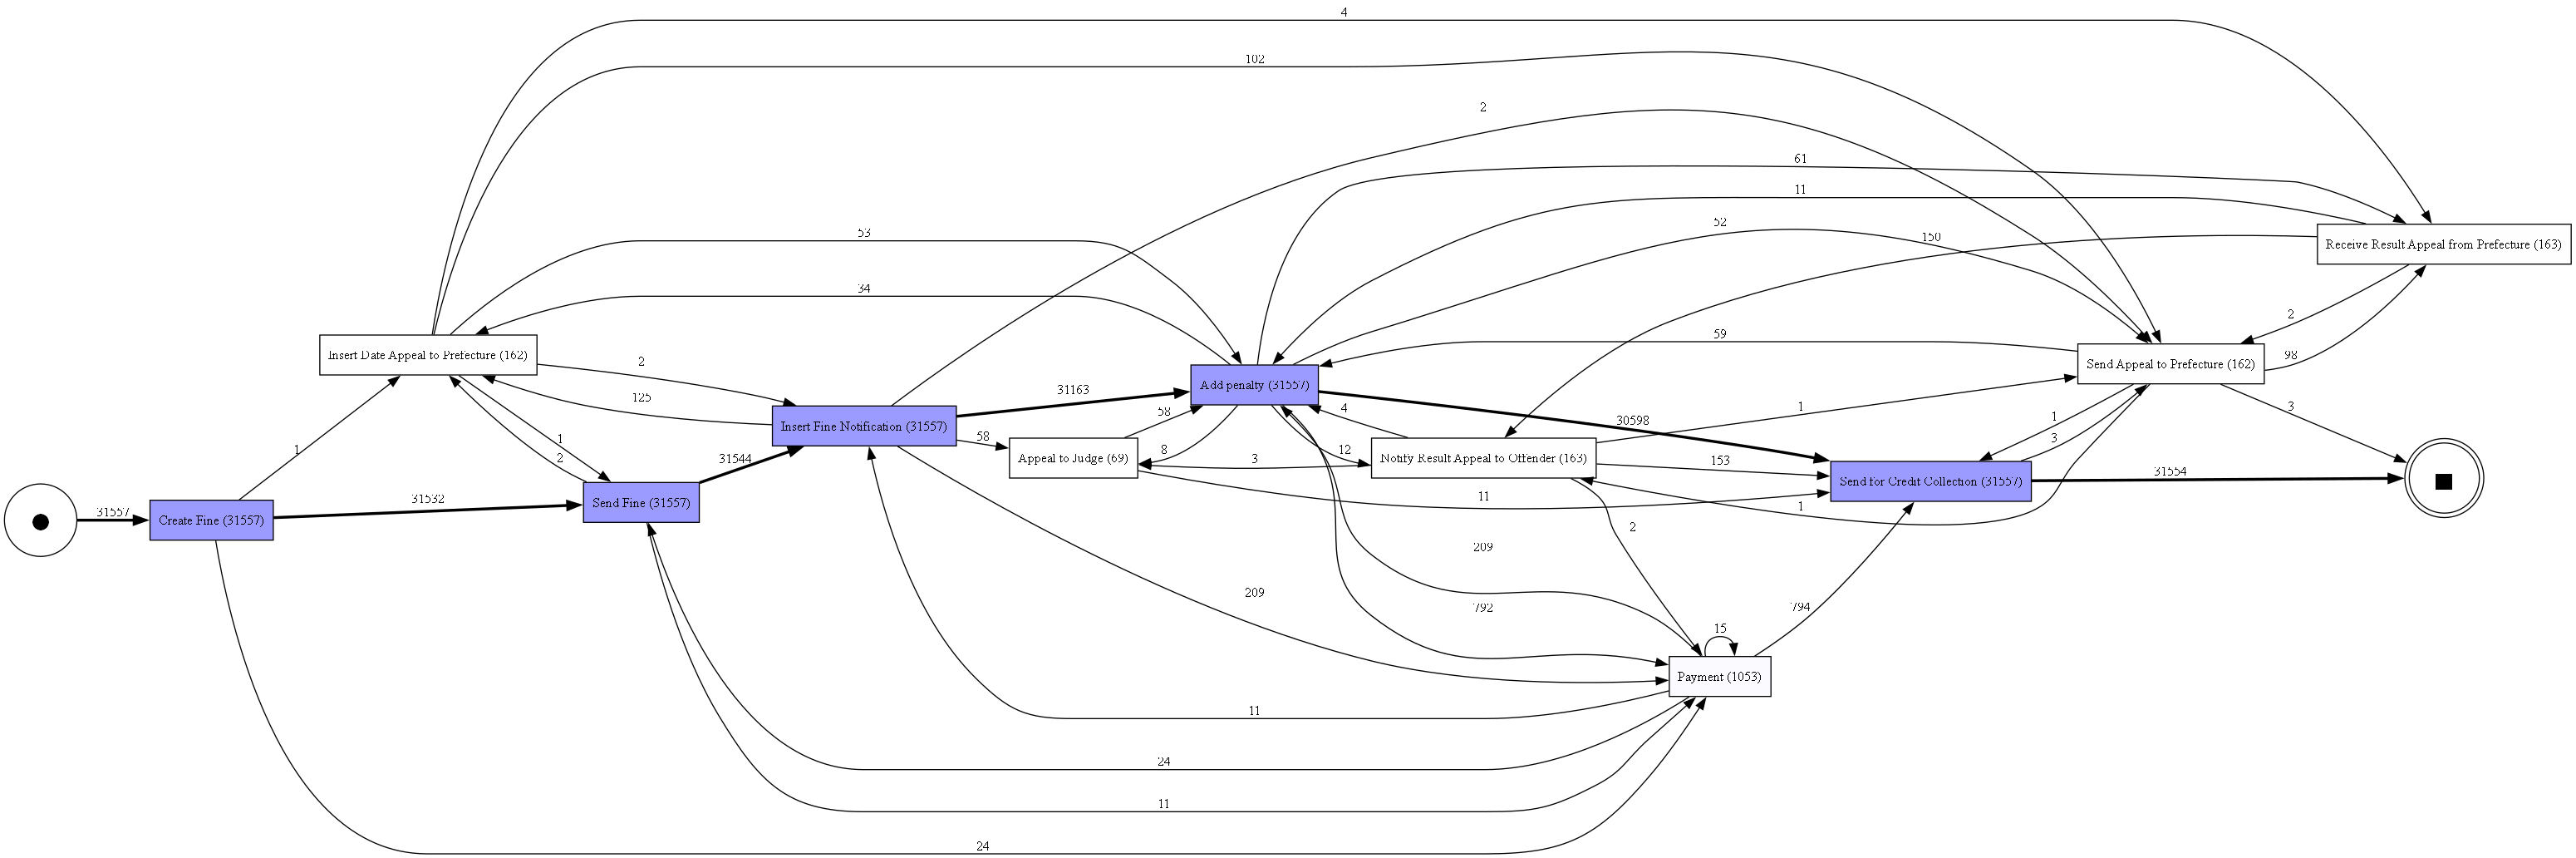

In [159]:
credit_dfg, credit_start, credit_end = pm4py.discover_dfg(sidebranch6_le87_credit)
pm4py.view_dfg(credit_dfg, credit_start, credit_end)

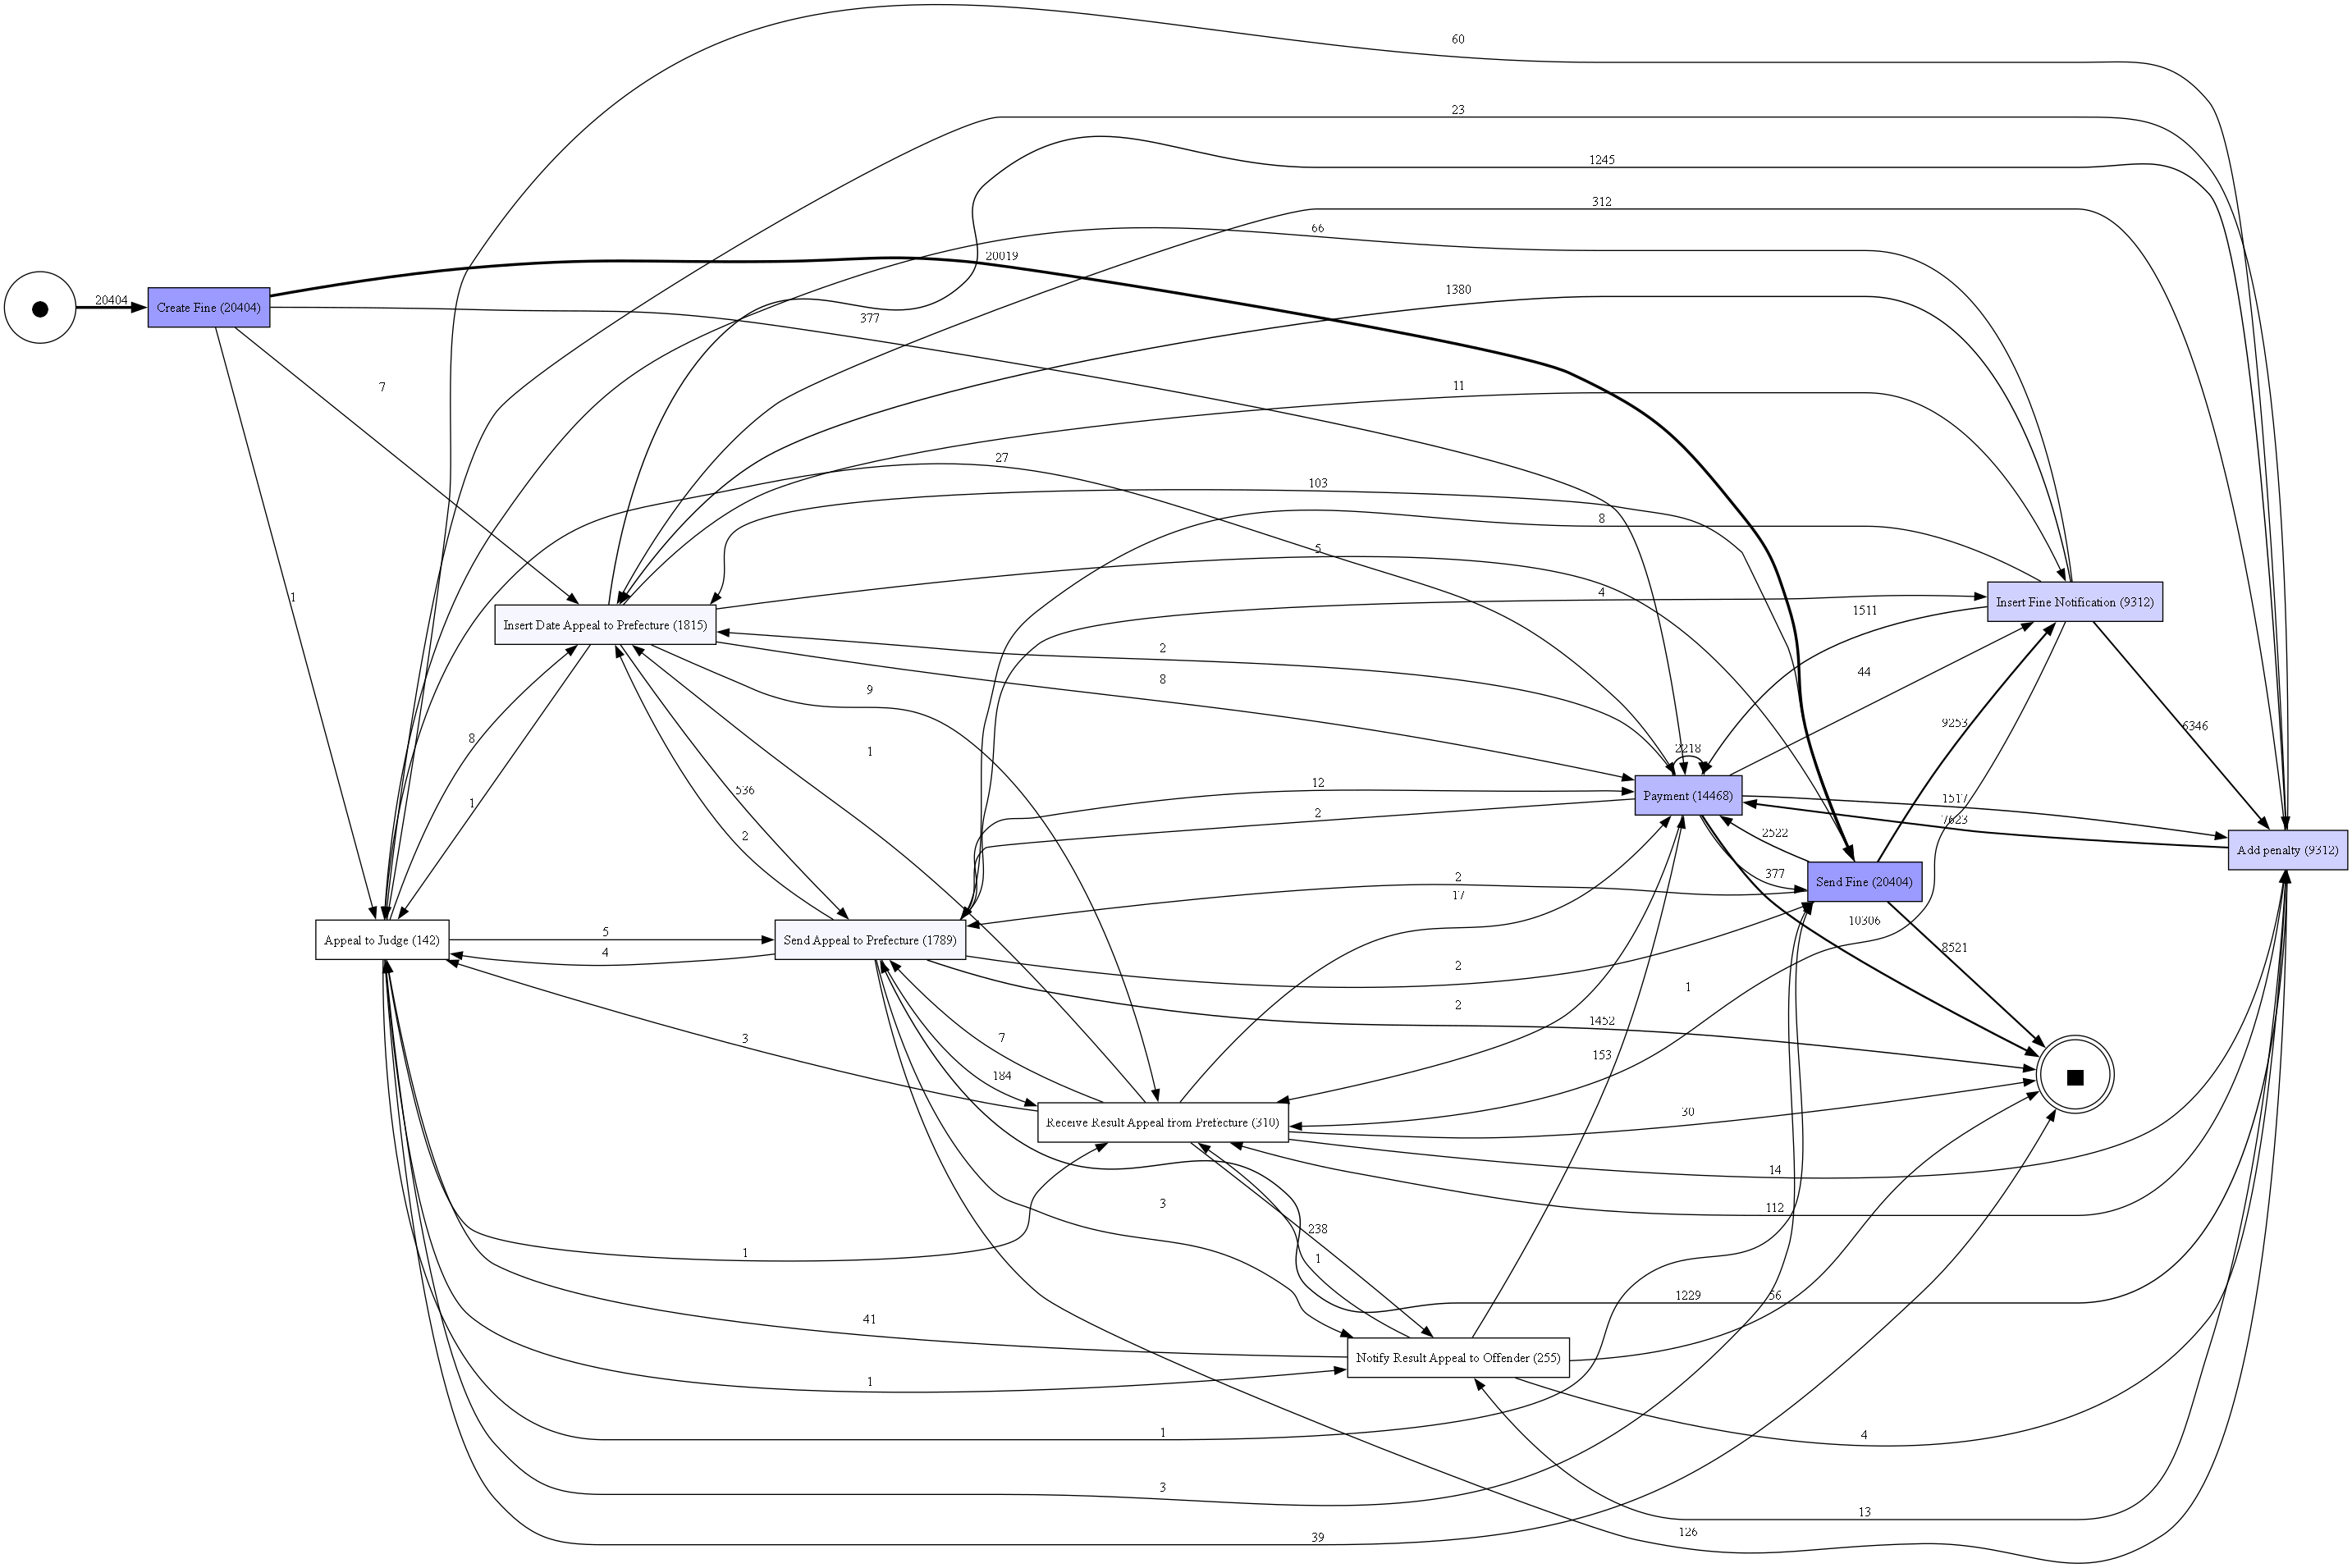

In [160]:
no_credit_dfg, no_credit_start, no_credit_end = pm4py.discover_dfg(sidebranch6_le87_no_credit)
pm4py.view_dfg(no_credit_dfg, no_credit_start, no_credit_end)

In [161]:
sidebranch6_payment_map = filterbranchmap(
    sidebranch6_view, result_set_name=None, source_log=sidebranch6_log,
    filters=sidebranch6_extended_filters, metric=sidebranch6_outstanding_metric,
    custom_metrics=BRANCHMAP_METRICS, allow_filter_selection=True,
    allow_reordering=True, allow_subset_saving=True
)

**Investigating Appeals and Dismissals**
- The participant next rereads the second and third temporal constraints.
- The third constraint states that, after receiving the notification, the offender may appeal the fine either to the prefecture or to a judge within 60 days. The participant also revisits the activity descriptions to clarify the role of the prefecture.
- The participant now looks specifically for cases in which an appeal is followed by dismissal of the fine. Because appeals to the prefecture and appeals to a judge are represented differently in the event log, the participant investigates these two circumstances separately.


In [162]:
def cases_with_followed_by_relation(event_log, first_activity, second_activity):
    """Return cases where the first activity is followed later in event order by the second activity."""

    matching_cases = set()
    sort_columns = [CASE_ID_COL, TIMESTAMP_COL] + (["@@index"] if "@@index" in event_log.columns else [])
    ordered_log = event_log.sort_values(sort_columns, kind="stable")

    for case_id, case in ordered_log.groupby(CASE_ID_COL, sort=False):
        activities = case[ACTIVITY_COL].tolist()
        first_position = next((i for i, activity in enumerate(activities) if activity == first_activity), None)

        if first_position is not None and second_activity in activities[first_position + 1:]:
            matching_cases.add(case_id)

    return matching_cases

In [163]:
# Find prefecture appeals and retain those dismissed with "#".

prefecture_appeal_cases = cases_with_followed_by_relation(log, "Send Fine", "Insert Date Appeal to Prefecture")
prefecture_dismissed_cases = set(log.loc[log["dismissal"].eq("#"), CASE_ID_COL])
prefecture_dismissed_after_appeal = prefecture_appeal_cases & prefecture_dismissed_cases

print(f"Cases where Send Fine is followed by Insert Date Appeal to Prefecture: {len(prefecture_appeal_cases):,}")
print(f"Appeal cases dismissed by the prefecture: {len(prefecture_dismissed_after_appeal):,}")

Cases where Send Fine is followed by Insert Date Appeal to Prefecture: 4,166
Appeal cases dismissed by the prefecture: 1,974


**Circumstance 2: Fine Dismissed by the Prefecture**

- The participant identifies cases in which *Send Fine* is eventually followed by *Insert Date Appeal to Prefecture*.
- This produces 4,166 appeal cases in the Python reconstruction.
- He then uses an OLAP table to inspect the `dismissal` attribute.
- The value `#` indicates dismissal by the prefecture.
- Intersecting the appeal subset with `dismissal = #` produces 1,974 cases.
- The participant concludes that payment was not made because the prefecture dismissed the fine and the offender was no longer required to pay.


<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 7: Appeal to the Prefecture

The analyst selects cases where `Send Fine` is eventually followed by `Insert Date Appeal to Prefecture`, then filters for `dismissal = "#"`, indicating dismissal by the prefecture.

The map confirms that prefecture dismissal explains non-payment in these cases. Its complement shows that approximately half of the appealed fines are not dismissed, which may warrant further investigation. Prefecture dismissals nevertheless represent only a small part of the full log.

</div>

In [164]:
# FilterBranchMap 7: Appeal to the prefecture

branch7_log, branch7_view = branchmap_log, branchmap_view

query_full_log_prefecture_appeal = Query("FullLog_SendFineEventuallyPrefectureAppeal", [EventuallyFollowsRelation([("Send Fine", "Insert Date Appeal to Prefecture")])])
query_prefecture_appeal_dismissed = Query("PrefectureAppeal_DismissalEqualsHash", [EqToConstant("dismissal", "#")])

branch7_filters = [query_full_log_prefecture_appeal, query_prefecture_appeal_dismissed]
branch7_selected_sublogs = show_branchmap(branch7_view, branch7_log, branch7_filters)

In [165]:
# Find cases where notification is followed by an appeal to a judge.
judge_appeal_cases = cases_with_followed_by_relation(log, "Insert Fine Notification", "Appeal to Judge")
print(f"Cases with notification followed by appeal to judge: {len(judge_appeal_cases):,}")

# Find all cases marked as dismissed by the judge.
judge_dismissed_cases = set(log.loc[log["dismissal"].eq("G"), CASE_ID_COL])
print(f"Cases dismissed by judge: {len(judge_dismissed_cases):,}")

# Find all cases dismissed by the judge after an appeal.
judge_dismissed_after_appeal = judge_appeal_cases & judge_dismissed_cases
print(f"Appeal-to-judge cases dismissed by judge: {len(judge_dismissed_after_appeal):,}")

Cases with notification followed by appeal to judge: 538
Cases dismissed by judge: 93
Appeal-to-judge cases dismissed by judge: 88


**Circumstance 3: Fine Dismissed by a Judge**

- The participant selects cases in which *Insert Fine Notification* is eventually followed by *Appeal to Judge*.
- This produces 538 appeal cases in the Python reconstruction.
- He identifies `G` as the dismissal value indicating dismissal by a judge.
- There are 93 judge-dismissal cases in the complete log.
- Intersecting the appeal subset with `dismissal = G` produces 88 cases.
- The participant concludes that the judge dismissed these fines and that the offenders were therefore no longer required to pay.

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 8: Appeal to a Judge

The analyst selects cases where `Insert Fine Notification` is eventually followed by `Appeal to Judge`, then filters for `dismissal = "G"`, indicating dismissal by the judge.

The dismissed subset contains only 88 cases and is therefore very small relative to the full log. The complementary branch shows that many judge appeals do not result in dismissal and may provide a separate direction for investigation.

</div>

In [ ]:
# FilterBranchMap 8: Appeal to a judge

branch8_log, branch8_view = branchmap_log, branchmap_view

query_full_log_judge_appeal = Query("FullLog_NotificationEventuallyJudgeAppeal", [EventuallyFollowsRelation([("Insert Fine Notification", "Appeal to Judge")])])
query_judge_appeal_dismissed = Query("JudgeAppeal_DismissalEqualsG", [EqToConstant("dismissal", "G")])

branch8_filters = [query_full_log_judge_appeal, query_judge_appeal_dismissed]
branch8_selected_sublogs = show_branchmap(branch8_view, branch8_log, branch8_filters)

In [167]:
# Reconstruct the event-level empty-dismissal filter. Celonis displays missing
# values as "−", whereas pandas imports them as NaN.

cases_with_empty_dismissal_event = set(log.loc[log["dismissal"].isna(), CASE_ID_COL])
attempted_unknown_reason_log = log.loc[log[CASE_ID_COL].isin(cases_with_empty_dismissal_event)].copy()

remaining_case_count = attempted_unknown_reason_log[CASE_ID_COL].nunique()
total_cases = log[CASE_ID_COL].nunique()

print(f"Cases remaining after the attempted empty-dismissal filter: {remaining_case_count:,}")
print(f"Cases in the complete event log: {total_cases:,}")
print(f"Share retained: {remaining_case_count / total_cases:.1%}")

Cases remaining after the attempted empty-dismissal filter: 150,370
Cases in the complete event log: 150,370
Share retained: 100.0%


**Attempted Investigation of Cases With an Unknown Reason**

- The participant realizes that some cases still lack an identified reason for non-payment.
- He attempts to isolate these cases by filtering for records where dismissal is displayed as `−`.
- In Celonis, `−` represents an empty value; after import into pandas, these values appear as `NaN`.
- Because the filter is applied at the event level, every case contains at least one event with an empty dismissal value.
- The filter therefore retains all 150,370 cases and does not isolate the intended subset.
- The participant does not recognize this problem and nevertheless interprets the result as cases with an unknown reason for non-payment.

<div style="border-left: 6px solid #c026d3; background: #fdf4ff; padding: 12px 16px; margin: 16px 0; border-radius: 6px; color: #4a044e;">

### FilterBranchMap 9: Attempted Unknown-Reason Subset

The analyst attempts to isolate cases with an empty dismissal value, displayed as `−` in Celonis. Because the filter is applied at the event level, a complete case passes whenever any of its events has an empty dismissal value.

The map shows that every case passes this filter, so it does not isolate the intended unknown-reason subset. This was also visible in the original analysis, but the analyst did not recognize the ineffective filter.

</div>

In [168]:
# FilterBranchMap 9: Attempted unknown-reason subset

branch9_log, branch9_view = branchmap_log, branchmap_view

branch9_log["dismissal_for_filter"] = branch9_log["dismissal"].where(
    branch9_log["dismissal"].notna(), "-"
).astype(str).str.strip()

query_full_log_contains_empty_dismissal = Query("FullLog_ContainsDismissalDash", [EventAttributeValues("dismissal_for_filter", "-")])

branch9_filters = [query_full_log_contains_empty_dismissal]
branch9_selected_sublogs = show_branchmap(branch9_view, branch9_log, branch9_filters)

### Participant Analysis Sequence

The tree below reconstructs the participant's original analysis. `[FILTER]` restricts the cases under investigation. `[VIEW]`, `[ANALYSIS]`, `[LOOKUP]`, and `[OBSERVATION]` do not introduce an additional case filter.

`🟣 [FILTERBRANCHMAP]` marks an interactive extension added after the original analysis. These maps were not part of the participant’s original actions.

```text
FULL LOG
│
├── 1 — INITIAL VARIANT EXPLORATION
│   │
│   ├── [VIEW] Most common variant
│   ├── [VIEW] Top 2 variants
│   ├── [VIEW] Top 3 variants
│   ├── [VIEW] Top 4 variants
│   └── [VIEW] All variants
│       │
│       └── [OBSERVATION]
│           The complete model is too complex.
│           The top 4 variants provide the clearest overview.
│
└── 🟣 [FILTERBRANCHMAP 1]
    Initial Variant Exploration


FULL LOG
│
├── 2 — CASES WITHOUT PAYMENT
│   │
│   ├── [LOOKUP]
│   │   Send for Credit Collection indicates that
│   │   the offender has not successfully paid the fine.
│   │
│   └── [FILTER] Contains Send for Credit Collection
│       │
│       ├── [OBSERVATION] Approximately 59,000 cases
│       ├── [VIEW] Top 4 variants
│       ├── [OBSERVATION]
│       │   Some credit-collection variants still contain Payment.
│       │
│       └── [FILTER] No Payment
│           │
│           ├── [OBSERVATION] Approximately 56,900 cases
│           ├── [VIEW] Top 4 variants
│           ├── [VIEW] Most common variant
│           ├── [ANALYSIS] Open OLAP table
│           ├── [LOOKUP] Review data attributes
│           └── [ANALYSIS] Close OLAP table
│
├── 🟣 [FILTERBRANCHMAP 2]
│   Cases Without Payment
│
└── 🟣 [SIMPLIFIED FILTERBRANCHMAP 2]
    Cases Without Payment, excluding variant filters


RESET / REMOVE ALL FILTERS
│
├── 3 — SUCCESSFUL-PAYMENT SUBSET
│   │
│   └── [FILTER] No Send for Credit Collection
│       │
│       └── [FILTER] At least one Payment
│           │
│           └── [VIEW / SELECTION] Top 6 variants
│               │
│               ├── [ANALYSIS]
│               │   Export selected variants as a BPMN model
│               │
│               ├── [ANALYSIS]
│               │   Clear the existing Conformance Checker model
│               │
│               ├── [ANALYSIS]
│               │   Upload the BPMN reference model
│               │
│               └── [ANALYSIS]
│                   Launch conformance analysis
│
├── 🟣 [FILTERBRANCHMAP 3]
│   Successful-Payment Subset
│
└── 🟣 [SIMPLIFIED FILTERBRANCHMAP 3]
    Successful-Payment Subset, excluding the variant filter


4 — CONFORMANCE ANALYSIS
│
├── [OBSERVATION]
│   44% conforming
│   56% non-conforming
│
└── [FILTER] Non-conforming cases
    │
    └── [OBSERVATION]
        Send for Credit Collection is the most common
        first undesired activity and occurs in approximately
        39% of all cases.
        │
        ├── [ANALYSIS] Drill down into deviation details
        │
        └── [ANALYSIS] Run root-cause analysis
            │
            ├── [ANALYSIS] Remove Activity
            ├── [ANALYSIS] Remove Timestamp
            ├── [ANALYSIS] Remove Amount
            ├── [ANALYSIS] Remove Celonis Change Date
            │
            ├── [OBSERVATION] Candidate explanations
            │   ├── Variant
            │   ├── Variant index
            │   └── totalPaymentAmount
            │
            └── [FINDING]
                The root-cause analysis does not identify
                a satisfactory explanation.

🟣 [FILTERBRANCHMAP 4]
Non-Conforming Credit-Collection Cases

🟣 [SIMPLIFIED FILTERBRANCHMAP 4]
Credit-Collection Cases, excluding the conformance filter


RESET / RETURN TO FULL LOG
│
├── 5 — CREDIT-COLLECTION VARIANTS
│   │
│   └── [FILTER] Contains Send for Credit Collection
│       │
│       ├── [VIEW] Top 4 variants
│       ├── [VIEW] Top 5 variants
│       └── [VIEW] Top 7 variants
│           │
│           └── [OBSERVATION]
│               The leading variants account for nearly
│               all credit-collection cases.
│
└── 🟣 [FILTERBRANCHMAP 5]
    Credit-Collection Variants


RESET / RETURN TO FULL LOG
│
├── 6 — DELAYED FINE
│   │
│   ├── [LOOKUP] Reread the temporal constraints
│   │
│   └── [FILTER]
│       Create Fine followed eventually by Send Fine
│       │
│       ├── [OBSERVATION]
│       │   Approximately 101,093 cases
│       │   67.2% of the complete event log
│       │
│       └── [FILTER]
│           More than 87 days between
│           Create Fine and Send Fine
│           │
│           ├── [OBSERVATION]
│           │   Approximately 52,026 cases
│           │
│           └── [FINDING]
│               The participant interprets the delay as
│               a possible reason for non-payment because
│               the offender may no longer be required to pay.
│
└── 🟣 [FILTERBRANCHMAP 6]
    Delayed Sending of the Fine


RESET / RETURN TO FULL LOG
│
├── 7 — APPEAL TO PREFECTURE
│   │
│   ├── [LOOKUP] Review the appeal constraints
│   ├── [LOOKUP] Review the meaning of prefecture
│   │
│   └── [FILTER]
│       Send Fine followed eventually by
│       Insert Date Appeal to Prefecture
│       │
│       ├── [LOOKUP]
│       │   dismissal = "#" means dismissed by prefecture
│       │
│       ├── [ANALYSIS] Open OLAP table
│       ├── [ANALYSIS] Use Case ID as dimension
│       ├── [ANALYSIS] Use dismissal as KPI
│       ├── [ANALYSIS] Sort dismissal values
│       │
│       └── [FILTER] dismissal = "#"
│           │
│           ├── [OBSERVATION] Approximately 1,970 cases
│           └── [FINDING]
│               The prefecture dismissed the fine,
│               so the offender was no longer required to pay.
│
└── 🟣 [FILTERBRANCHMAP 7]
    Appeal to the Prefecture


RESET / REMOVE ALL FILTERS
│
├── 8 — APPEAL TO JUDGE
│   │
│   └── [FILTER]
│       Insert Fine Notification followed eventually by
│       Appeal to Judge
│       │
│       ├── [OBSERVATION] 538 appeal cases
│       ├── [LOOKUP]
│       │   dismissal = "G" means dismissed by judge
│       │
│       └── [FILTER] dismissal = "G"
│           │
│           ├── [VIEW] Return to Variant Explorer
│           ├── [OBSERVATION] 88 cases
│           └── [FINDING]
│               The judge dismissed the fine,
│               so the offender was no longer required to pay.
│
└── 🟣 [FILTERBRANCHMAP 8]
    Appeal to a Judge


RESET / REMOVE ALL FILTERS
│
├── 9 — ATTEMPTED UNKNOWN-REASON SUBSET
│   │
│   └── [FILTER] dismissal = "−"
│       │
│       ├── [OBSERVATION]
│       │   The filter is applied incorrectly.
│       │   No cases are excluded.
│       │   The complete event log remains.
│       │
│       └── [FINDING]
│           The participant nevertheless interprets the result
│           as cases with an unknown reason for non-payment.
│           This conclusion is not supported by the applied filter.
│
└── 🟣 [FILTERBRANCHMAP 9]
    Attempted Unknown-Reason Subset
```
